# Clustering-based feature augmentation for fine-grained question classification on the TREC dataset

Giorgio Baselice, 886186 \
Hadis Forghani, 920040 \
Amaiza Jamil, 885861

# SEED SETTING

In [ ]:
# Set the global seed for reproducibilty
SEED = 42

import os
import random
import numpy as np
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)

np.random.seed(SEED)

import torch
torch.manual_seed(SEED) # CPU
torch.cuda.manual_seed(SEED) # Current GPU
torch.cuda.manual_seed_all(SEED) # All the GPUs

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# DATA LOADING

Main references for the TREC dataset:

- Li, Xin e Roth, Dan (2002). *Learning Question Classifiers*. COLING 2002. [Link](https://www.aclweb.org/anthology/C02-1150)
- Hovy, Eduard et al. (2001). *Toward Semantics-Based Answer Pinpointing*. First International Conference on Human Language Technology Research. [Link](https://www.aclweb.org/anthology/H01-1069)

Code for the TREC dataset copied from GitHub:

- [TensorFlow Datasets – TREC](https://github.com/tensorflow/datasets/tree/master/tensorflow_datasets/datasets/trec/trec_dataset_builder.py)

In [ ]:
_URLs = {
    "train": "http://cogcomp.org/Data/QA/QC/train_5500.label",
    "test": "http://cogcomp.org/Data/QA/QC/TREC_10.label",
}

_COARSE_LABELS = ["DESC", "ENTY", "ABBR", "HUM", "NUM", "LOC"]

_FINE_LABELS = [
    "manner",
    "cremat",
    "animal",
    "exp",
    "ind",
    "gr",
    "title",
    "def",
    "date",
    "reason",
    "event",
    "state",
    "desc",
    "count",
    "other",
    "letter",
    "religion",
    "food",
    "country",
    "color",
    "termeq",
    "city",
    "body",
    "dismed",
    "mount",
    "money",
    "product",
    "period",
    "substance",
    "sport",
    "plant",
    "techmeth",
    "volsize",
    "instru",
    "abb",
    "speed",
    "word",
    "lang",
    "perc",
    "code",
    "dist",
    "temp",
    "symbol",
    "ord",
    "veh",
    "weight",
    "currency",
]

In [ ]:
%%writefile trec_dataset.py

# coding=utf-8
# Copyright 2025 The TensorFlow Datasets Authors.
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

_URLs = {
    "train": "http://cogcomp.org/Data/QA/QC/train_5500.label",
    "test": "http://cogcomp.org/Data/QA/QC/TREC_10.label",
}

_COARSE_LABELS = ["DESC", "ENTY", "ABBR", "HUM", "NUM", "LOC"]

_FINE_LABELS = [
    "manner",
    "cremat",
    "animal",
    "exp",
    "ind",
    "gr",
    "title",
    "def",
    "date",
    "reason",
    "event",
    "state",
    "desc",
    "count",
    "other",
    "letter",
    "religion",
    "food",
    "country",
    "color",
    "termeq",
    "city",
    "body",
    "dismed",
    "mount",
    "money",
    "product",
    "period",
    "substance",
    "sport",
    "plant",
    "techmeth",
    "volsize",
    "instru",
    "abb",
    "speed",
    "word",
    "lang",
    "perc",
    "code",
    "dist",
    "temp",
    "symbol",
    "ord",
    "veh",
    "weight",
    "currency",
]

"""The Text REtrieval Conference (TREC) Question Classification dataset."""

from tensorflow_datasets.core.utils.lazy_imports_utils import tensorflow as tf
import tensorflow_datasets.public_api as tfds

class Trec(tfds.core.GeneratorBasedBuilder):
  """TREC Dataset."""

  VERSION = tfds.core.Version("1.0.0")

  def _info(self):
    return self.dataset_info_from_configs(
        features=tfds.features.FeaturesDict({
            "label-coarse": tfds.features.ClassLabel(names=_COARSE_LABELS),
            "label-fine": tfds.features.ClassLabel(names=_FINE_LABELS),
            "text": tfds.features.Text(),
        }),
        # If there's a common (input, target) tuple from the features,
        # specify them here. They'll be used if as_supervised=True in
        # builder.as_dataset.
        supervised_keys=None,
        # Homepage of the dataset for documentation
        homepage="https://cogcomp.seas.upenn.edu/Data/QA/QC/",
    )

  def _split_generators(self, dl_manager):
    """Returns SplitGenerators."""

    dl_files = dl_manager.download_and_extract(_URLs)
    return [
        tfds.core.SplitGenerator(
            name=tfds.Split.TRAIN,
            gen_kwargs={
                "filepath": dl_files["train"],
            },
        ),
        tfds.core.SplitGenerator(
            name=tfds.Split.TEST,
            gen_kwargs={
                "filepath": dl_files["test"],
            },
        ),
    ]

  def _generate_examples(self, filepath):
    """Yields examples."""

    with tf.io.gfile.GFile(filepath, "rb") as f:
      for id_, row in enumerate(f):
        # One non-ASCII byte: sisterBADBYTEcity. We replace it with a space
        label, _, text = (
            row.replace(b"\xf0", b" ").strip().decode().partition(" ")
        )
        coarse_label, _, fine_label = label.partition(":")
        yield id_, {
            "label-coarse": coarse_label,
            "label-fine": fine_label,
            "text": text,
        }


Writing trec_dataset.py


In [ ]:
from trec_dataset import Trec

builder = Trec()
builder.download_and_prepare()

train = builder.as_dataset(split="train")
test = builder.as_dataset(split="test")

print("Dataset Loaded Correctly")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/trec/incomplete.HBRPOI_1.0.0/trec-train.tfrecord*...:   0%|          | 0/5…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/trec/incomplete.HBRPOI_1.0.0/trec-test.tfrecord*...:   0%|          | 0/50…

Dataset trec downloaded and prepared to /root/tensorflow_datasets/trec/1.0.0. Subsequent calls will reuse this data.
Dataset Loaded Correctly


In [ ]:
import pandas as pd

def tfds_to_dataframe(ds):
    rows = []
    for example in ds:
        rows.append({
            "text": example["text"].numpy().decode("utf-8"),
            "label-coarse": int(example["label-coarse"].numpy()),
            "label-fine": int(example["label-fine"].numpy()),
        })
    return pd.DataFrame(rows)

In [ ]:
# Converti i dataset TFDS in Pandas DataFrame
df_train = tfds_to_dataframe(train)
df_test = tfds_to_dataframe(test)

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

Train shape: (5452, 3)
Test shape: (500, 3)


In [ ]:
print(df_train.head())
print(df_test.head())

                                                text  label-coarse  label-fine
0                     Who was Camp David named for ?             3           4
1               What is the C programming language ?             0           7
2        Where is the oldest living thing on earth ?             5          14
3  How many claws has a lobster called a pistol l...             4          13
4  What son of a 15-year-old Mexican girl and a h...             3           4
                                                text  label-coarse  label-fine
0                   Where is the volcano Mauna Loa ?             5          14
1  Who was the abolitionist who led the raid on H...             3           4
2                  When was Lyndon B. Johnson born ?             4           8
3  What planet has the strongest magnetic field o...             5          14
4  What is the only artery that carries blue bloo...             1          22


In [ ]:
# Save the data related to train in separate variables
train_text = df_train["text"]
train_label_coarse = df_train["label-coarse"]
train_label_fine = df_train["label-fine"]

# Save the data related to test in separate variables
test_text = df_test["text"]
test_label_coarse = df_test["label-coarse"]
test_label_fine = df_test["label-fine"]

# DATA EXPLORATION

In [ ]:
import pandas as pd
import numpy as np
import re
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("notebook")


In [ ]:
# Label name mappings (from the dataset definition in trec_dataset.py)
COARSE_LABELS = ['DESC', 'ENTY', 'ABBR', 'HUM', 'NUM', 'LOC']
FINE_LABELS = [
    "manner","cremat","animal","exp","ind","gr","title","def","date","reason",
    "event","state","desc","count","other","letter","religion","food","country",
    "color","termeq","city","body","dismed","mount","money","product","period",
    "substance","sport","plant","techmeth","volsize","instru","abb","speed",
    "word","lang","perc","code","dist","temp","symbol","ord","veh","weight","currency"
]

# Add readable label columns (keeps original numeric labels intact)
df_train = df_train.copy()
df_test  = df_test.copy()

df_train["coarse_name"] = df_train["label-coarse"].map(lambda i: COARSE_LABELS[i] if 0 <= i < len(COARSE_LABELS) else "UNK")
df_test["coarse_name"]  = df_test["label-coarse"].map(lambda i: COARSE_LABELS[i] if 0 <= i < len(COARSE_LABELS) else "UNK")

df_train["fine_name"] = df_train["label-fine"].map(lambda i: FINE_LABELS[i] if 0 <= i < len(FINE_LABELS) else "UNK")
df_test["fine_name"]  = df_test["label-fine"].map(lambda i: FINE_LABELS[i] if 0 <= i < len(FINE_LABELS) else "UNK")

df_train.head()


,text,label-coarse,label-fine,coarse_name,fine_name
0,Who was Camp David named for ?,3,4,HUM,ind
1,What is the C programming language ?,0,7,DESC,def
2,Where is the oldest living thing on earth ?,5,14,LOC,other
3,How many claws has a lobster called a pistol l...,4,13,NUM,count
4,What son of a 15-year-old Mexican girl and a h...,3,4,HUM,ind


In [ ]:
# 1) Basic sanity checks
print("Train shape:", df_train.shape)
print("Test shape :", df_test.shape)

print("\nMissing values (train):")
display(df_train.isna().mean().sort_values(ascending=False).to_frame("missing_rate"))

print("\nMissing values (test):")
display(df_test.isna().mean().sort_values(ascending=False).to_frame("missing_rate"))

dup_train = df_train.duplicated(subset=["text", "label-coarse", "label-fine"]).mean()
dup_test  = df_test.duplicated(subset=["text", "label-coarse", "label-fine"]).mean()
print(f"\nDuplicate rows rate (train): {dup_train:.3%}")
print(f"Duplicate rows rate (test) : {dup_test:.3%}")


Train shape: (5452, 5)
Test shape : (500, 5)

Missing values (train):


,missing_rate
text,0.0
label-coarse,0.0
label-fine,0.0
coarse_name,0.0
fine_name,0.0



Missing values (test):


,missing_rate
text,0.0
label-coarse,0.0
label-fine,0.0
coarse_name,0.0
fine_name,0.0



Duplicate rows rate (train): 1.284%
Duplicate rows rate (test) : 0.000%


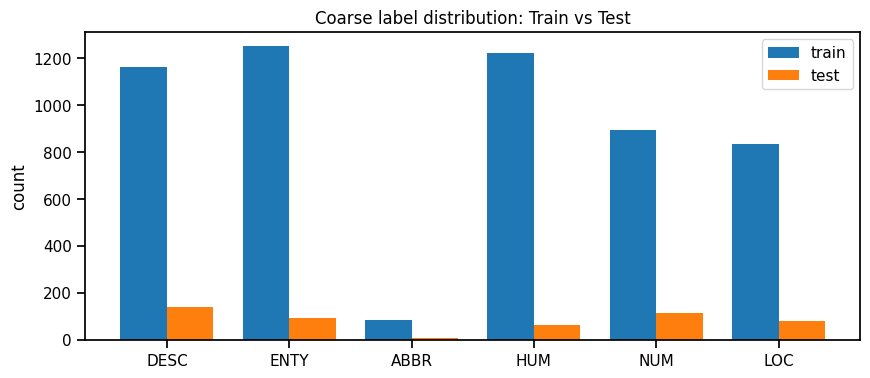

In [ ]:
# 2) Label distribution (coarse) - train vs test
train_counts = df_train["coarse_name"].value_counts().reindex(COARSE_LABELS)
test_counts  = df_test["coarse_name"].value_counts().reindex(COARSE_LABELS)

fig, ax = plt.subplots(figsize=(10,4))
x = np.arange(len(COARSE_LABELS))
w = 0.38
ax.bar(x - w/2, train_counts.values, width=w, label="train")
ax.bar(x + w/2, test_counts.values,  width=w, label="test")
ax.set_xticks(x)
ax.set_xticklabels(COARSE_LABELS)
ax.set_title("Coarse label distribution: Train vs Test")
ax.set_ylabel("count")
ax.legend()
plt.show()



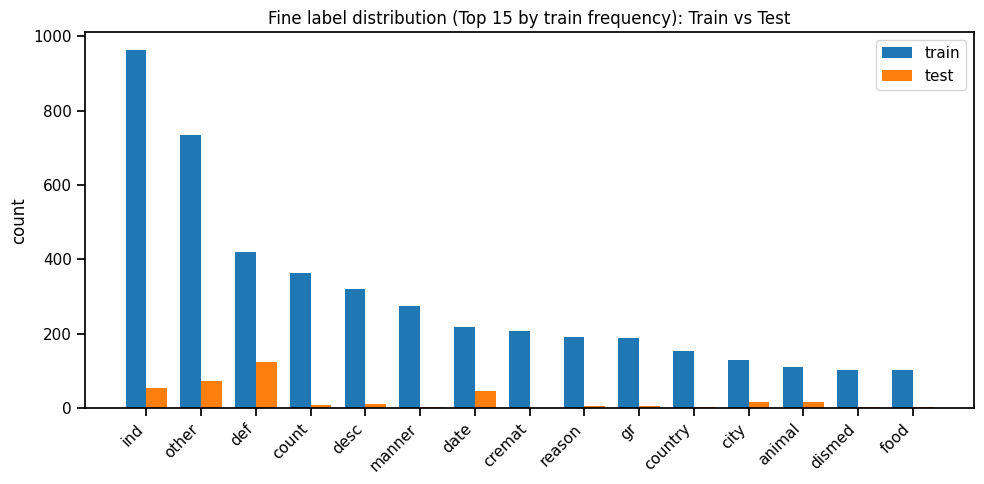

In [ ]:
# 3) Label distribution (fine) - show top 15 (fine labels are many)
top_n = 15
fine_train_top = df_train["fine_name"].value_counts().head(top_n)
fine_test_top  = df_test["fine_name"].value_counts().reindex(fine_train_top.index).fillna(0)

fig, ax = plt.subplots(figsize=(10,5))
x = np.arange(len(fine_train_top.index))
w = 0.38
ax.bar(x - w/2, fine_train_top.values, width=w, label="train")
ax.bar(x + w/2, fine_test_top.values,  width=w, label="test")
ax.set_xticks(x)
ax.set_xticklabels(fine_train_top.index, rotation=45, ha="right")
ax.set_title(f"Fine label distribution (Top {top_n} by train frequency): Train vs Test")
ax.set_ylabel("count")
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# 4) Text length features (characters and words)
def word_count(s: str) -> int:
    return len(str(s).split())

df_train["n_chars"] = df_train["text"].astype(str).str.len()
df_test["n_chars"]  = df_test["text"].astype(str).str.len()

df_train["n_words"] = df_train["text"].astype(str).apply(word_count)
df_test["n_words"]  = df_test["text"].astype(str).apply(word_count)

display(df_train[["n_chars","n_words"]].describe().T)


,count,mean,std,min,25%,50%,75%,max
n_chars,5452.0,50.632062,20.743208,13.0,36.0,48.0,61.0,196.0
n_words,5452.0,10.204696,3.889021,3.0,7.0,10.0,12.0,37.0


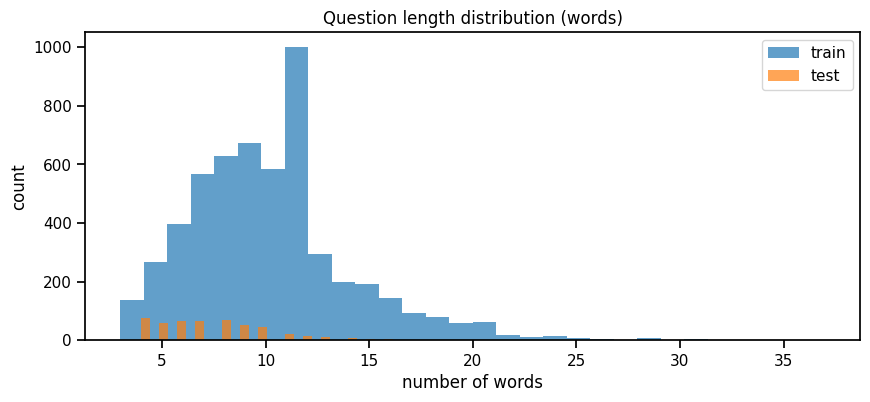

In [ ]:
# 5) Length distributions (overall)
fig, ax = plt.subplots(figsize=(10,4))
ax.hist(df_train["n_words"], bins=30, alpha=0.7, label="train")
ax.hist(df_test["n_words"],  bins=30, alpha=0.7, label="test")
ax.set_title("Question length distribution (words)")
ax.set_xlabel("number of words")
ax.set_ylabel("count")
ax.legend()
plt.show()


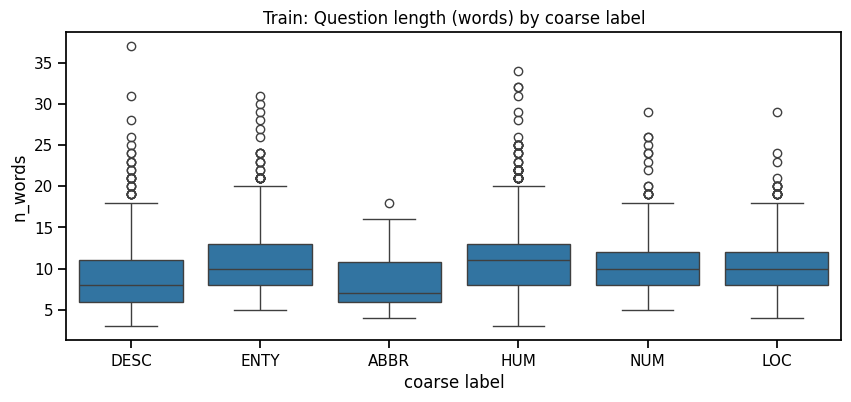

In [ ]:
# 6) Length by coarse label (do classes differ in question length?)
order = COARSE_LABELS

fig, ax = plt.subplots(figsize=(10,4))
sns.boxplot(data=df_train, x="coarse_name", y="n_words", order=order, ax=ax)
ax.set_title("Train: Question length (words) by coarse label")
ax.set_xlabel("coarse label")
ax.set_ylabel("n_words")
plt.show()


In [ ]:
# 7) Example questions per coarse label (quick qualitative check)
np.random.seed(42)
samples = (
    df_train.groupby("coarse_name", group_keys=False)
    .apply(lambda g: g.sample(3, random_state=42)[["coarse_name","fine_name","text"]])
    .sort_values("coarse_name")
)

display(samples)

/tmp/ipython-input-4069352288.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(3, random_state=42)[["coarse_name","fine_name","text"]])


,coarse_name,fine_name,text
5131,ABBR,exp,What does EKG stand for ?
16,ABBR,abb,What is the abbreviation of the International ...
4545,ABBR,exp,What does `` B.Y.O.B. '' mean ?
1209,DESC,desc,Where did the term `` 86 '' come from ?
496,DESC,desc,What is the difference between microprocessors...
5062,DESC,manner,How do I find a city if I have the area code ?
4826,ENTY,techmeth,Name a technique widely used to detect birth d...
1719,ENTY,event,What was the longest war in U.S. history ?
3055,ENTY,termeq,What was originally defined as one 1-millionth...
2849,HUM,ind,Whose funeral train traveled from Washington D...


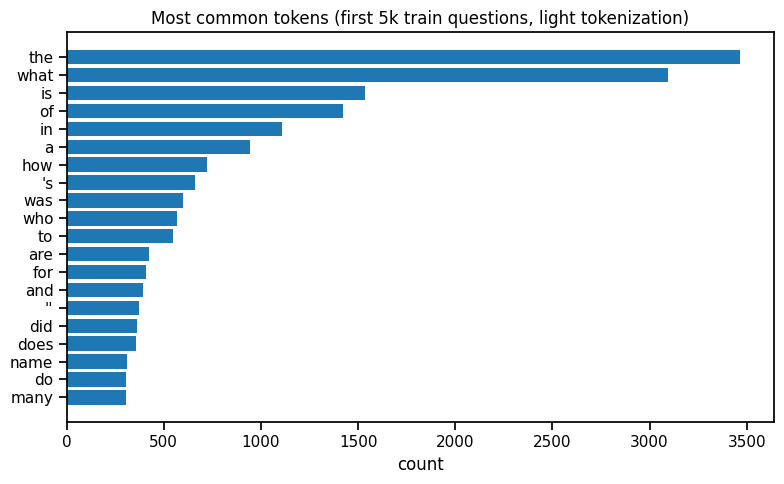

,word,count
0,the,3467
1,what,3096
2,is,1538
3,of,1421
4,in,1111
5,a,945
6,how,723
7,'s,663
8,was,599
9,who,570


In [ ]:
# 8) Quick vocabulary peek (very light cleaning)
def basic_tokenize(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()

tokens = []
for t in df_train["text"].head(5000):  # speed limit
    tokens.extend(basic_tokenize(t))

top_words = Counter(tokens).most_common(20)
top_words_df = pd.DataFrame(top_words, columns=["word","count"])

fig, ax = plt.subplots(figsize=(8,5))
ax.barh(top_words_df["word"][::-1], top_words_df["count"][::-1])
ax.set_title("Most common tokens (first 5k train questions, light tokenization)")
ax.set_xlabel("count")
plt.tight_layout()
plt.show()

display(top_words_df)



# TEXT PREPROCESSING - GENERAL

In [ ]:
# Whitespaces normalization and strip leading and trailing spaces

## Train text
train_text = train_text.str.split().str.join(" ")

## test text
test_text = test_text.str.split().str.join(" ")

print("First question of the train set: \"", train_text[1], "\"")
print("First question of the test set: \"", test_text[1], "\"")

First question of the train set: " What is the C programming language ? "
First question of the test set: " Who was the abolitionist who led the raid on Harper 's Ferry in 1859 ? "


# SENTENCE REPRESENTATION - SBERT

In [ ]:
from sentence_transformers import SentenceTransformer

# Loading of the pre-trained SBERT model
sbert_model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# Extraction of the sentences to embed
train_sentences = train_text.tolist()
test_sentences = test_text.tolist()

train_sbert = sbert_model.encode(train_sentences, convert_to_numpy=True, show_progress_bar=True)
print("SBERT train embeddings ready. Shape:", train_sbert.shape)

test_sbert = sbert_model.encode(test_sentences, convert_to_numpy=True, show_progress_bar=True)
print("SBERT test embeddings ready. Shape:", test_sbert.shape)

Batches:   0%|          | 0/171 [00:00<?, ?it/s]

SBERT train embeddings ready. Shape: (5452, 768)


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

SBERT test embeddings ready. Shape: (500, 768)


# TEXT CLUSTERING

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [ ]:
K_RANGE = range(30, 70)
silhouette_scores = {}
best_k = 0
best_score = -1
best_model = None

print("Computing Silhouette Score for K-Means...")

for k in K_RANGE:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
        )
    labels = kmeans.fit_predict(train_sbert)

    score = silhouette_score(train_sbert, labels, metric='cosine')
    silhouette_scores[k] = score

    if score > best_score:
        best_score = score
        best_k = k
        best_model = kmeans

    print(f"K={k}: Silhouette Score = {score:.4f}")

print("\n--- Optimal score (Slihouette Score) ---")
print(f"Optimal K: {best_k}")
print(f"Silhouette Score: {best_score:.4f}")




Computing Silhouette Score for K-Means...
K=30: Silhouette Score = 0.0542
K=31: Silhouette Score = 0.0529
K=32: Silhouette Score = 0.0545
K=33: Silhouette Score = 0.0541
K=34: Silhouette Score = 0.0551
K=35: Silhouette Score = 0.0557
K=36: Silhouette Score = 0.0545
K=37: Silhouette Score = 0.0575
K=38: Silhouette Score = 0.0562
K=39: Silhouette Score = 0.0560
K=40: Silhouette Score = 0.0594
K=41: Silhouette Score = 0.0595
K=42: Silhouette Score = 0.0586
K=43: Silhouette Score = 0.0601
K=44: Silhouette Score = 0.0559
K=45: Silhouette Score = 0.0565
K=46: Silhouette Score = 0.0606
K=47: Silhouette Score = 0.0614
K=48: Silhouette Score = 0.0575
K=49: Silhouette Score = 0.0564
K=50: Silhouette Score = 0.0615
K=51: Silhouette Score = 0.0616
K=52: Silhouette Score = 0.0595
K=53: Silhouette Score = 0.0572
K=54: Silhouette Score = 0.0584
K=55: Silhouette Score = 0.0584
K=56: Silhouette Score = 0.0610
K=57: Silhouette Score = 0.0593
K=58: Silhouette Score = 0.0651
K=59: Silhouette Score = 0.059

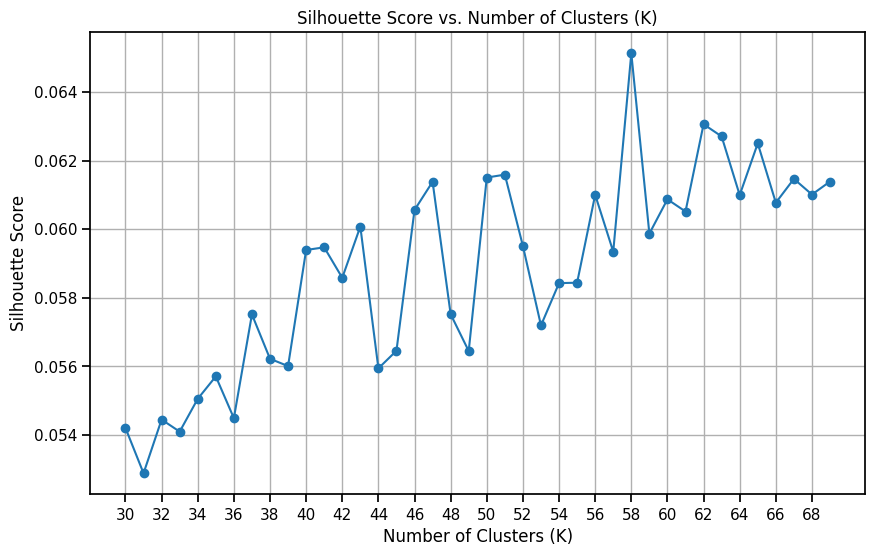

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters (K)')
plt.grid(True)
plt.xticks(list(K_RANGE)[::2]) # Show fewer x-ticks for better readability
plt.show()

In [ ]:
train_cluster_labels = best_model.predict(train_sbert)
test_cluster_labels = best_model.predict(test_sbert)

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics.cluster import contingency_matrix

def cluster_purity_score(y_true, y_pred):
    M = contingency_matrix(y_true, y_pred)

    dominant_classes_sum = np.sum(np.max(M, axis=0))

    purity = dominant_classes_sum / len(y_true)

    return purity

In [ ]:
purity = cluster_purity_score(train_label_coarse, train_cluster_labels)
print("Train set cluster purity w.r.t. coarse-labels:", purity)

purity = cluster_purity_score(train_label_fine, train_cluster_labels)
print("Train set cluster purity w.r.t. fine-labels:", purity)

Train set cluster purity w.r.t. coarse-labels: 0.6109684519442407
Train set cluster purity w.r.t. fine-labels: 0.44845928099779897


# FEATURE PREPARATION

In [ ]:
train_distances = kmeans.transform(train_sbert)
test_distances  = kmeans.transform(test_sbert)

train_distance_to_assigned = train_distances[
    np.arange(len(train_cluster_labels)),
    train_cluster_labels
]

test_distance_to_assigned = test_distances[
    np.arange(len(test_cluster_labels)),
    test_cluster_labels
]

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

centroids = kmeans.cluster_centers_

train_centroid_similarity = cosine_similarity(train_sbert,
                                              centroids)
test_centroid_similarity  = cosine_similarity(test_sbert,
                                              centroids)

In [ ]:
train_features = np.hstack([
    train_distances,                 # distance to all centroids
    train_centroid_similarity,       # similarity to all centroids
    train_distance_to_assigned[:, None]
])

test_features = np.hstack([
    test_distances,
    test_centroid_similarity,
    test_distance_to_assigned[:, None]
])

display(train_features.shape)
display(test_features.shape)

(5452, 139)

(500, 139)

# TEXT PREPROCESSING - TF-IDF

In [ ]:
# Transform all data in lowercase
train_text_tfidf = train_text.str.lower()
test_text_tfidf = test_text.str.lower()

print("First question of the train set: \"", train_text_tfidf[1], "\"")
print("First question of the test set: \"", test_text_tfidf[1], "\"")

First question of the train set: " what is the c programming language ? "
First question of the test set: " who was the abolitionist who led the raid on harper 's ferry in 1859 ? "


## TEXT TOKENIZATION WITH SPACY

In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm")

def tokenize_spacy(text):
    doc = nlp(text)

    # 1-grmas
    unigrams = [token.text for token in doc if not token.is_space]

    # 2-grmas
    bigrams = [
        unigrams[i] + " " + unigrams[i+1]
        for i in range(len(unigrams)-1)
    ]

    return unigrams + bigrams

In [ ]:
train_tokens_tfidf = train_text_tfidf.apply(tokenize_spacy)
test_tokens_tfidf = test_text_tfidf.apply(tokenize_spacy)

print("Train set tokenization (fist 5 sentences): \n",  train_tokens_tfidf.head(), "\n")
print("Test set tokenization (fist 5 sentences): \n", test_tokens_tfidf.head())

Train set tokenization (fist 5 sentences): 
 0    [who, was, camp, david, named, for, ?, who was...
1    [what, is, the, c, programming, language, ?, w...
2    [where, is, the, oldest, living, thing, on, ea...
3    [how, many, claws, has, a, lobster, called, a,...
4    [what, son, of, a, 15, -, year, -, old, mexica...
Name: text, dtype: object 

Test set tokenization (fist 5 sentences): 
 0    [where, is, the, volcano, mauna, loa, ?, where...
1    [who, was, the, abolitionist, who, led, the, r...
2    [when, was, lyndon, b., johnson, born, ?, when...
3    [what, planet, has, the, strongest, magnetic, ...
4    [what, is, the, only, artery, that, carries, b...
Name: text, dtype: object


# TEXT REPRESENTATION - TF-IDF

In [ ]:
# Imprt sklearn for TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
# Define a vectorizer which does not use the tokenizer of sklearn
vectorizer_tfidf = TfidfVectorizer(
    tokenizer=lambda x: x,       # obtain directly the list of tokens
    preprocessor=lambda x: x,    # does not apply any pre-processing
    token_pattern=None,          # disable internal tokenization
    norm='l2',
    max_df=0.95,
    max_features=10000
)

In [ ]:
train_tfidf = vectorizer_tfidf.fit_transform(train_tokens_tfidf)
test_tfidf = vectorizer_tfidf.transform(test_tokens_tfidf)

display(train_tfidf.shape)
display(test_tfidf.shape)

(5452, 10000)

(500, 10000)

# CLASSIFICATION DATA PREPARATION

In [ ]:
train_tfidf_feat = np.hstack([train_tfidf.toarray(), train_features])
test_tfidf_feat = np.hstack([test_tfidf.toarray(), test_features])

display(train_tfidf_feat.shape)
display(test_tfidf_feat.shape)

(5452, 10139)

(500, 10139)

In [ ]:
train_sbert_feat = np.hstack([train_sbert, train_features])
test_sbert_feat = np.hstack([test_sbert, test_features])

display(train_sbert_feat.shape)
display(test_sbert_feat.shape)

(5452, 907)

(500, 907)

In [ ]:
train_full = np.hstack([train_tfidf.toarray(), train_sbert, train_features])
test_full = np.hstack([test_tfidf.toarray(), test_sbert, test_features])

display(train_full.shape)
display(test_full.shape)

(5452, 10907)

(500, 10907)

# TEXT CLASSIFICATION - IMPORTS AND FUNCTIONS

In [ ]:
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
def print_f1_scores(y_pred):
    f1_micro = f1_score(test_label_fine, y_pred, average='micro')
    f1_macro = f1_score(test_label_fine, y_pred, average='macro')
    f1_weighted = f1_score(test_label_fine, y_pred, average='weighted')

    print("F1 micro:", f1_micro)
    print("F1 macro:", f1_macro)
    print("F1 weighted:", f1_weighted)


def show_examples(X_test, y_pred, num_examples=5):

    # Find indices of correct and incorrect predictions
    correct_idx = [i for i in range(len(test_label_fine)) if test_label_fine[i] == y_pred[i]]
    wrong_idx = [i for i in range(len(test_label_fine)) if test_label_fine[i] != y_pred[i]]

    print(f"Some correctly classified examples (max {num_examples}):\n")
    for i in correct_idx[:3]:
        print(f"Question: {X_test[i]}")
        print(f"True Label: {test_label_fine[i]}, Prediction: {y_pred[i]}")
        print("---")

    print("\n")
    print(f"Some misclassified examples (max {num_examples}):\n")
    for i in wrong_idx[:num_examples]:
        print(f"Question: {X_test[i]}")
        print(f"True Label: {test_label_fine[i]}, Prediction: {y_pred[i]}")
        print("---")

def plot_confusion_matrix(y_pred, labels=_FINE_LABELS):
    # Calculate the confusion matrix
    cm = confusion_matrix(test_label_fine, y_pred, labels=range(len(labels)))

    # Row normalization (percentage of correctness per class)
    # This is done in orther to make colors more readable when classes
    # have very different numbers of samples
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums!=0)

    # Diagonal always noted, off-diagonal only if > 0
    annot_matrix = np.where(np.eye(cm.shape[0], dtype=bool), cm, np.where(cm > 0, cm, ''))

    plt.figure(figsize=(22, 18))

    sns.heatmap(
        cm_norm,                     # use normalized values ​​for colors
        annot=annot_matrix,
        fmt='',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels,
        cbar=True,
        square=True
    )

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix (normalizzata)')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# TEXT CLASSIFICATION BASELINE - TF-IDF ONLY

## Logistic Regression

In [ ]:
# Logistic Regression Model (multiclass)
tfidf_baseline_reg_model = LogisticRegression(
    max_iter=3000,
    multi_class='multinomial',
    solver='lbfgs',
    C=0.5,
    penalty='l2',
    n_jobs=-1,
    random_state=42
)

In [ ]:
# Train of the model
tfidf_baseline_reg_model.fit(train_tfidf, train_label_fine)

# Prediction
tfidf_baseline_reg_out = tfidf_baseline_reg_model.predict(test_tfidf)

print("Accuracy:", accuracy_score(test_label_fine, tfidf_baseline_reg_out))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.676


f1 scores:
-- -- --
F1 micro: 0.676
F1 macro: 0.28694471839180313
F1 weighted: 0.6046675588277993
-- -- -- 

confusion matrix:
-- -- --


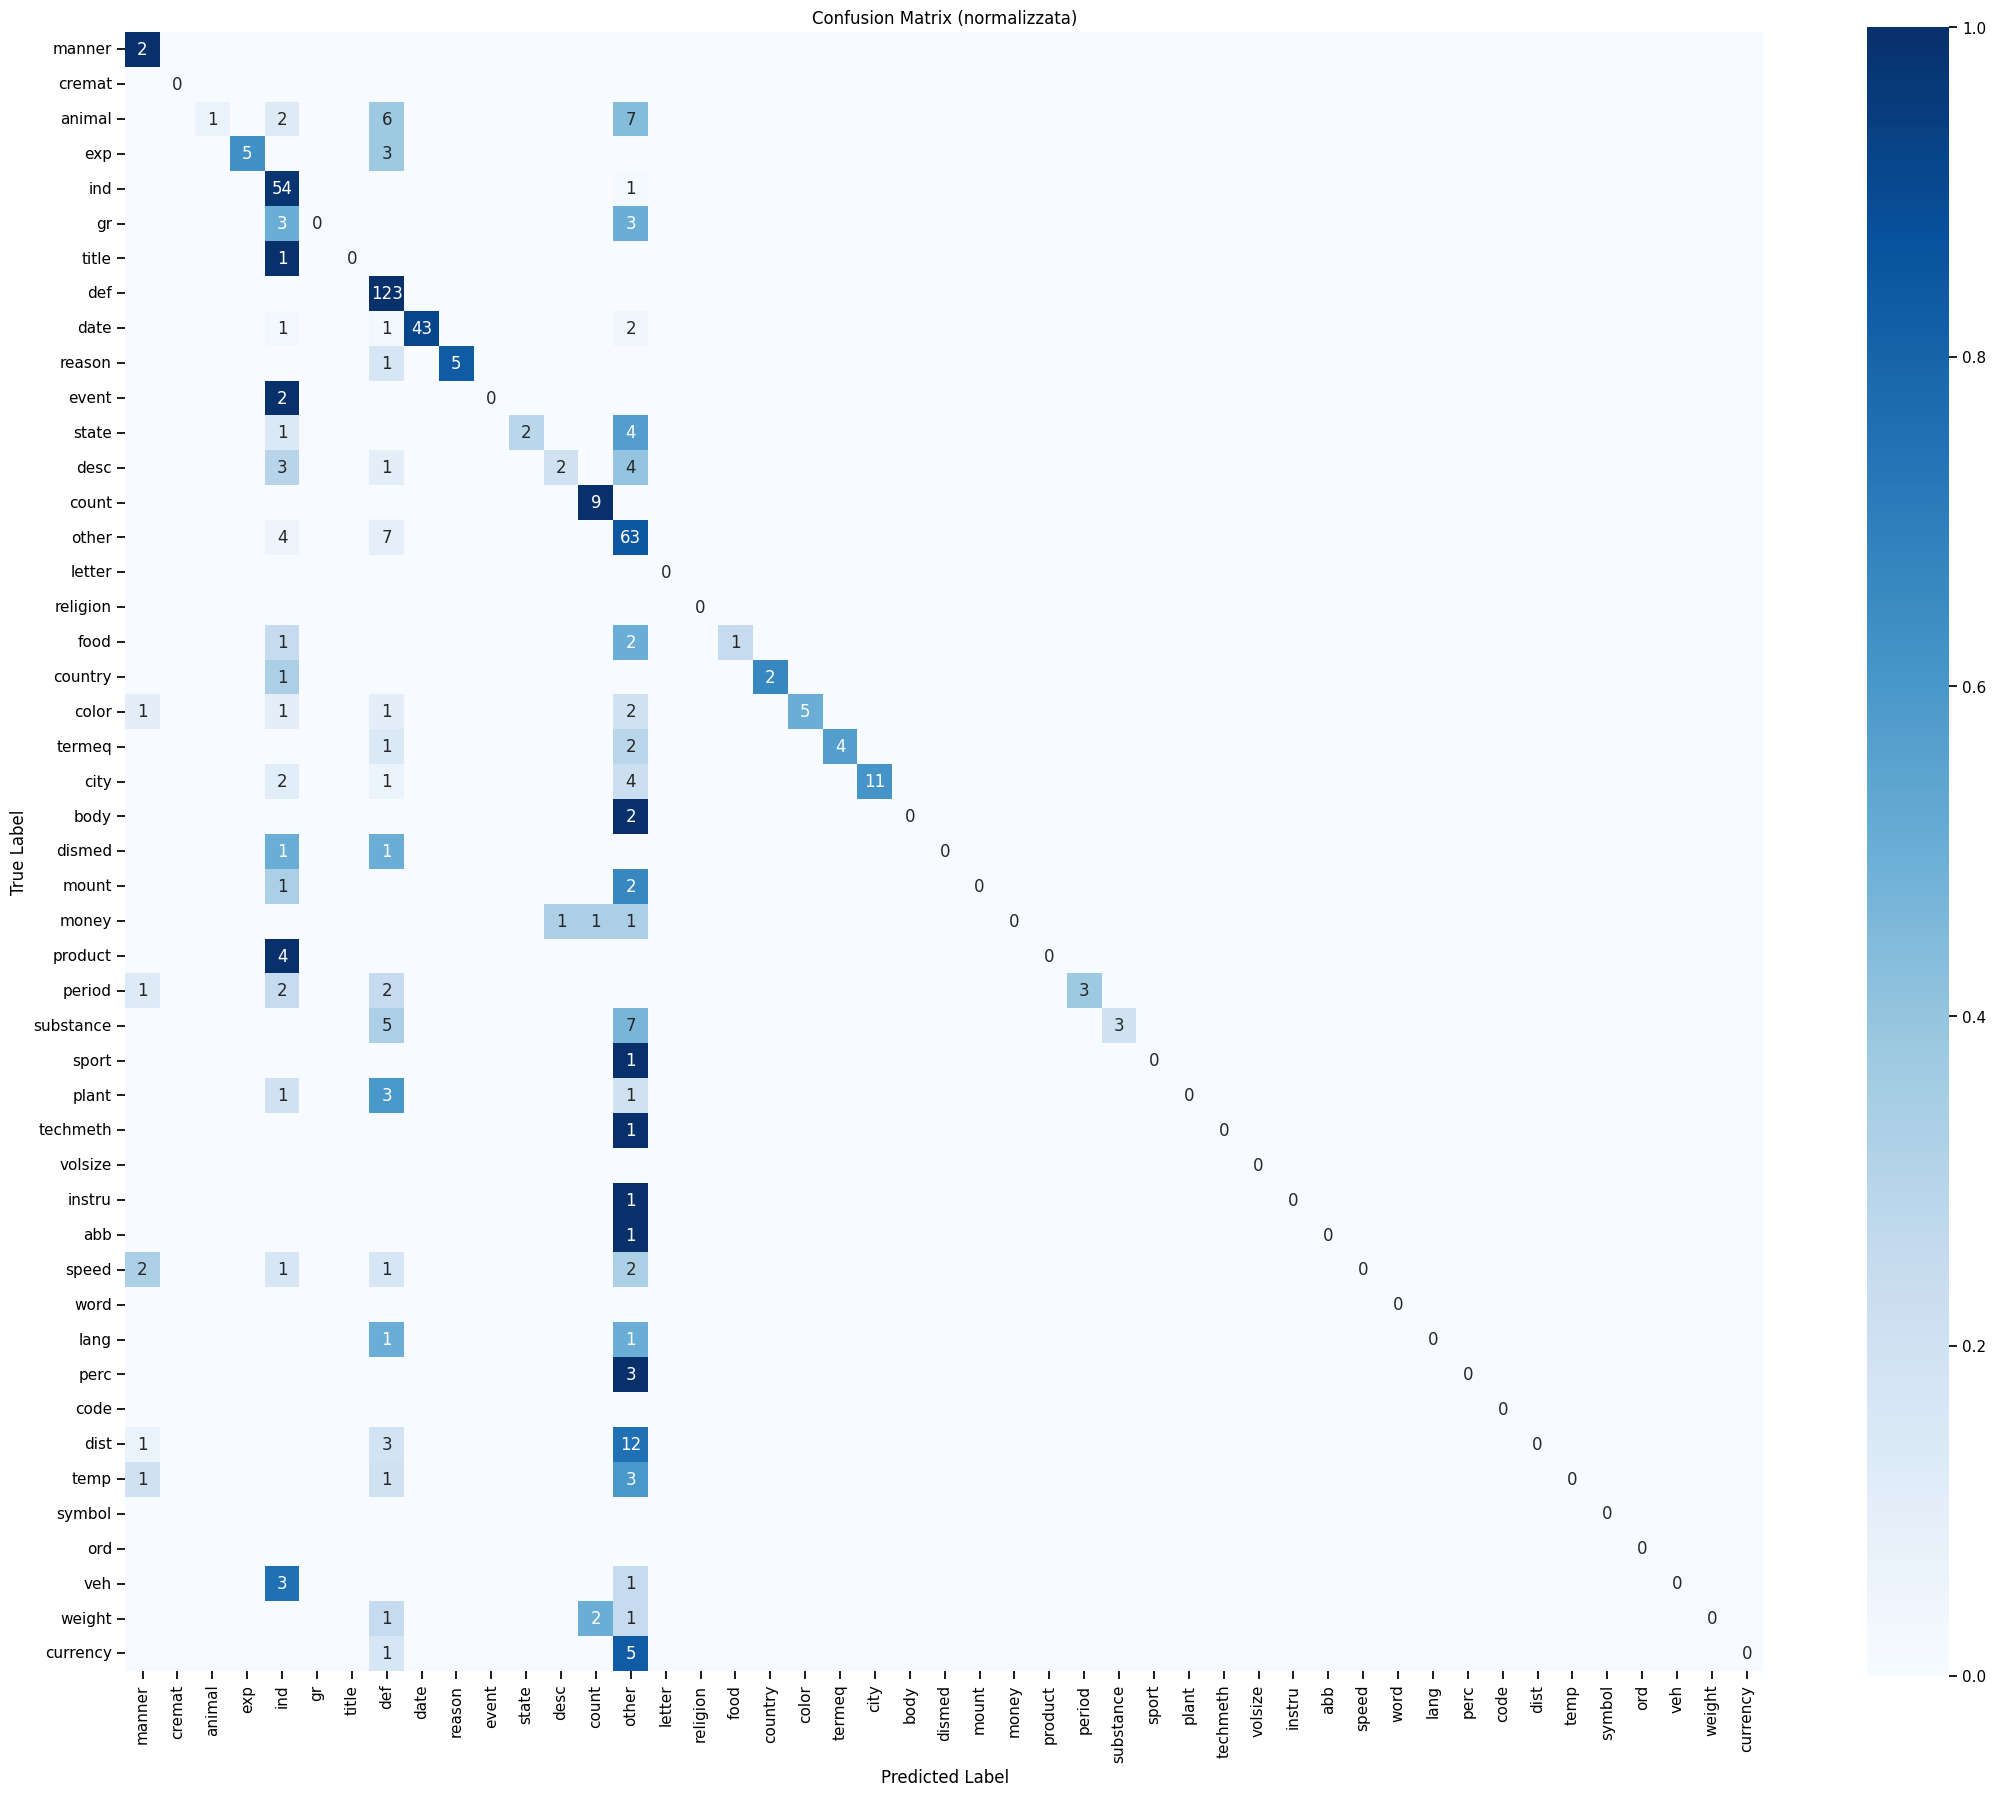

-- -- -- 

Some classification examples:
-- -- --
Some correctly classified examples (max 5):

Question: Where is the volcano Mauna Loa ?
True Label: 14, Prediction: 14
---
Question: Who was the abolitionist who led the raid on Harper 's Ferry in 1859 ?
True Label: 4, Prediction: 4
---
Question: When was Lyndon B. Johnson born ?
True Label: 8, Prediction: 8
---


Some misclassified examples (max 5):

Question: What is the only artery that carries blue blood from the heart to the lungs ?
True Label: 22, Prediction: 14
---
Question: How far is Pluto from the sun ?
True Label: 40, Prediction: 14
---
Question: What is the criterion for being legally blind ?
True Label: 14, Prediction: 7
---
Question: How much was a ticket for the Titanic ?
True Label: 25, Prediction: 13
---
Question: What is the date of Mexico 's independence ?
True Label: 8, Prediction: 14
---
-- -- --


In [ ]:
print("f1 scores:")
print("-- -- --")
print_f1_scores(tfidf_baseline_reg_out)
print("-- -- -- \n")

print("confusion matrix:")
print("-- -- --")
plot_confusion_matrix(tfidf_baseline_reg_out)
print("-- -- -- \n")

print("Some classification examples:")
print("-- -- --")
show_examples(test_text, tfidf_baseline_reg_out)
print("-- -- --")

## Linear SVM

In [ ]:
# Creation of the Linear SVM model
tfidf_baseline_svm_model = LinearSVC(random_state=42)

In [ ]:
tfidf_baseline_svm_model.fit(train_tfidf, train_label_fine)

tfidf_baseline_svm_out = tfidf_baseline_svm_model.predict(test_tfidf)

print("Accuracy:", accuracy_score(test_label_fine, tfidf_baseline_svm_out))

Accuracy: 0.844


f1 scores:
-- -- --
F1 micro: 0.844
F1 macro: 0.739040838807359
F1 weighted: 0.8327914909420532
-- -- -- 

confusion matrix:
-- -- --


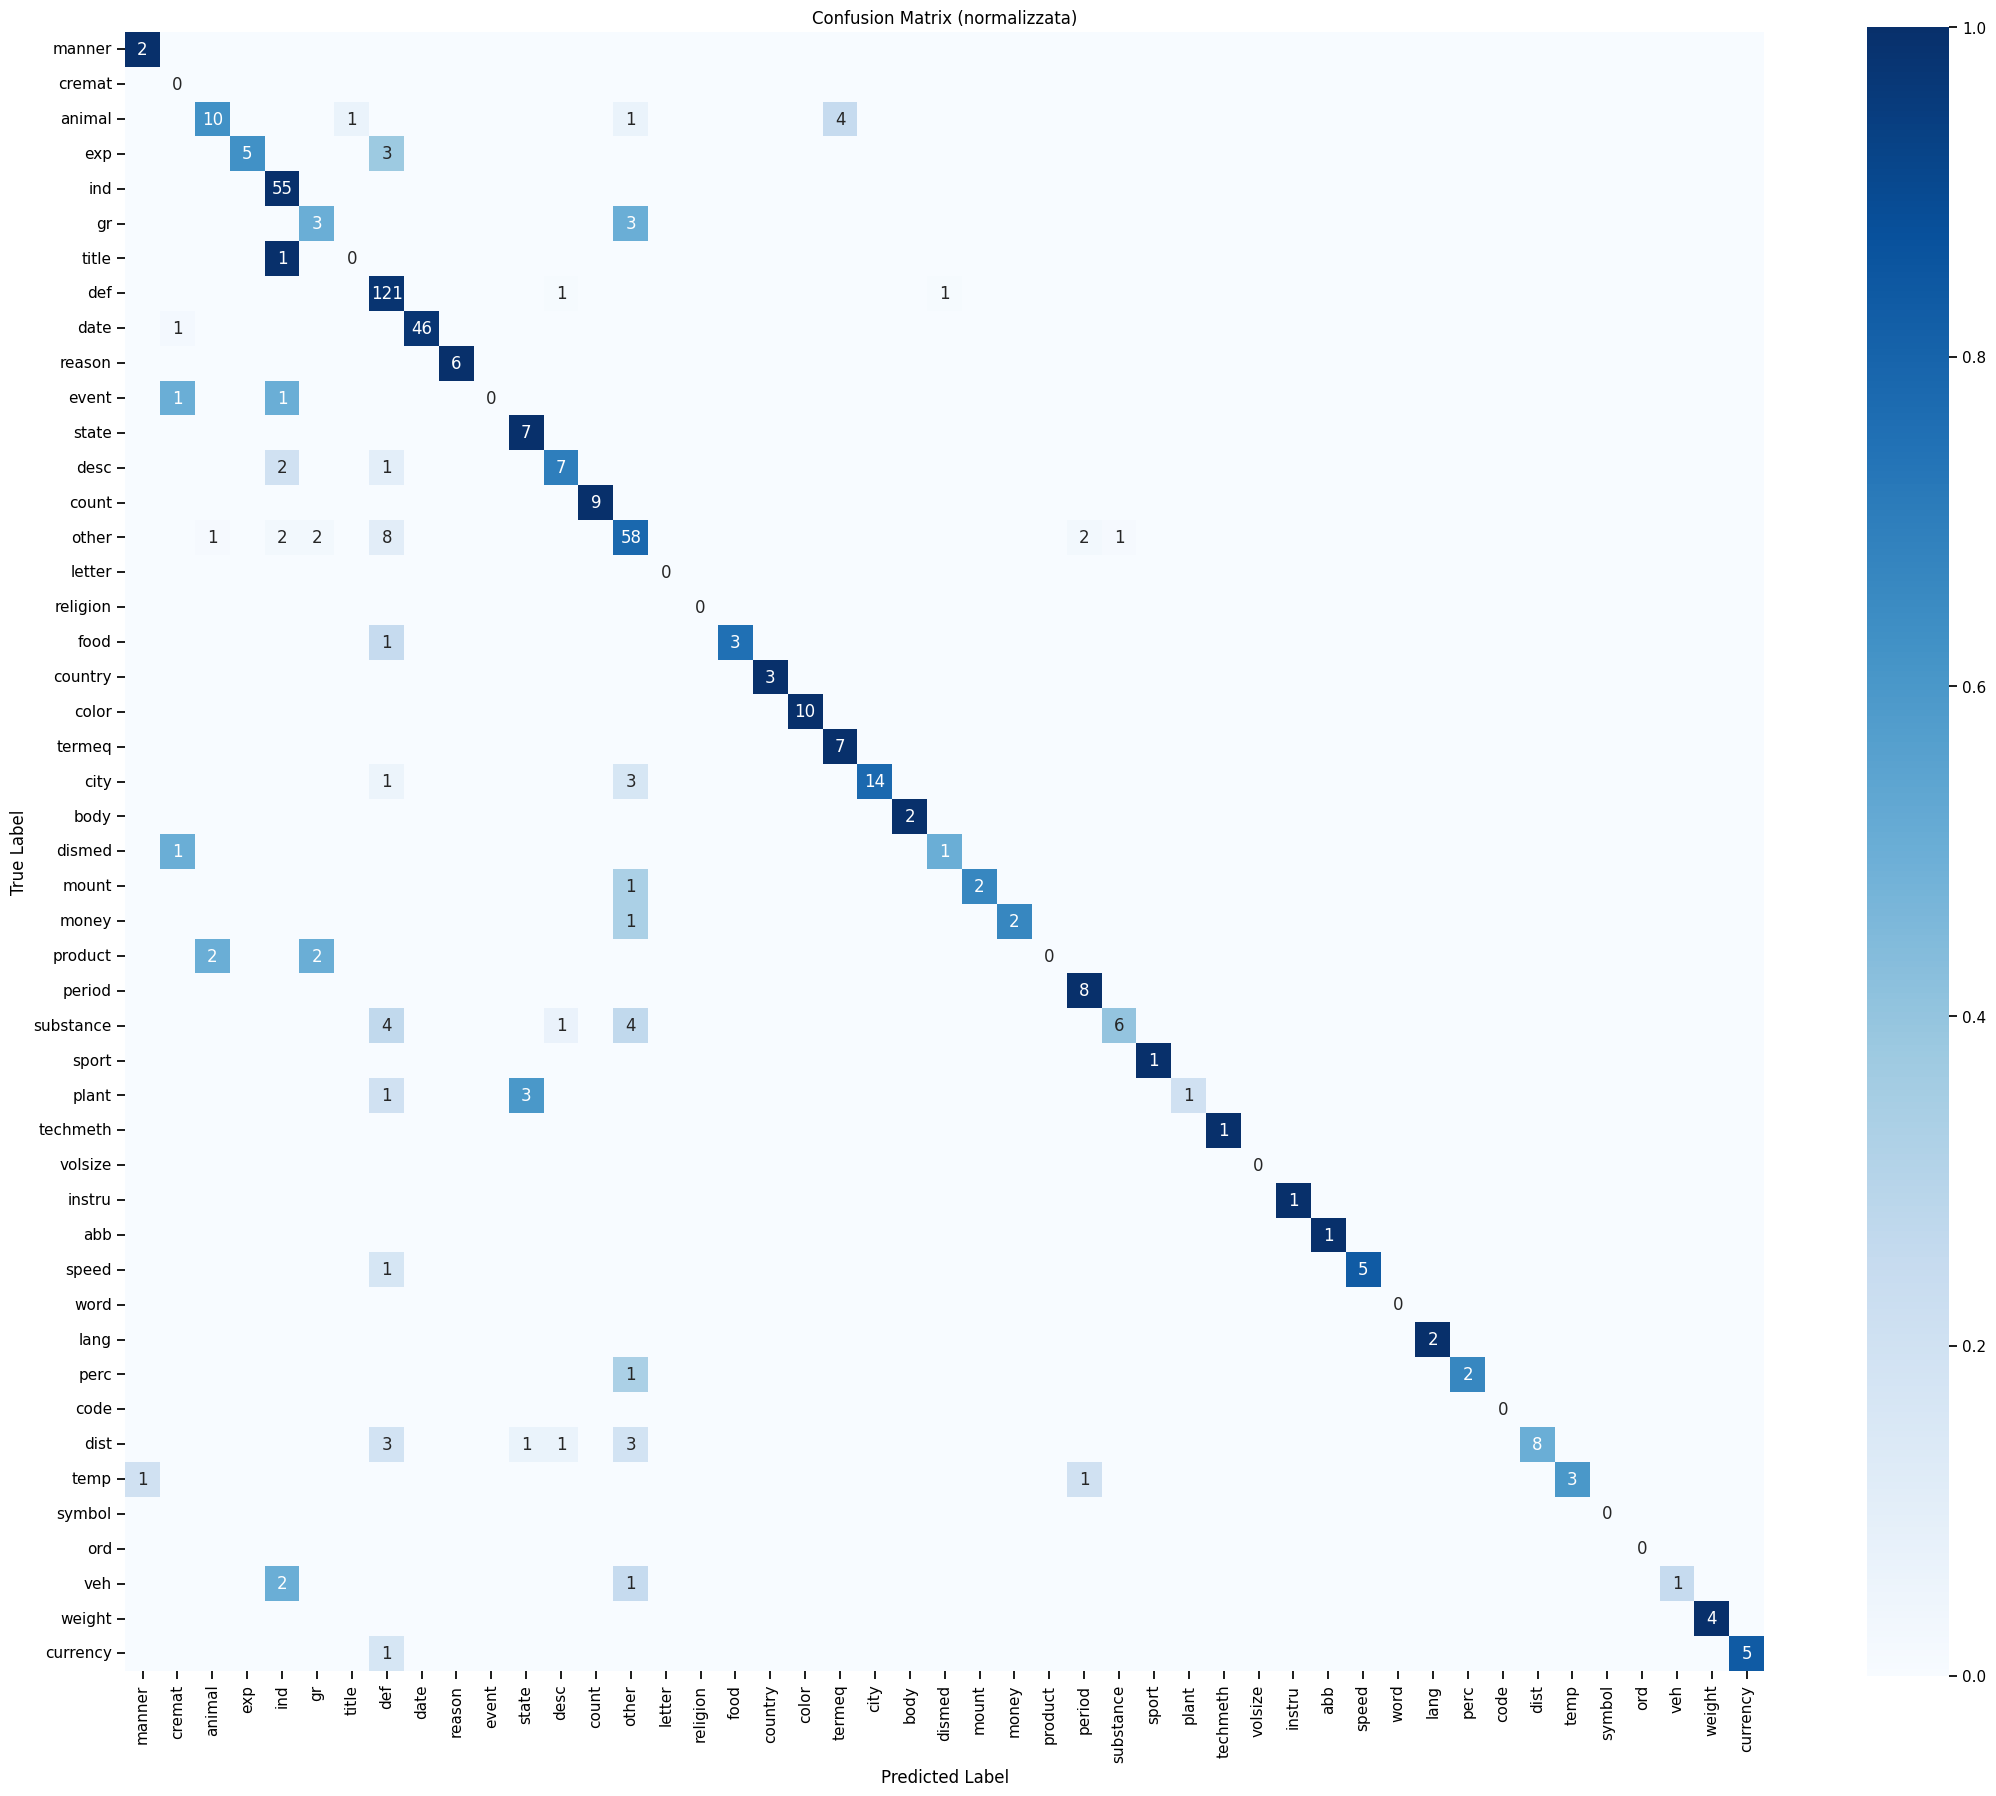

-- -- -- 

Some classification examples:
-- -- --
Some correctly classified examples (max 5):

Question: Where is the volcano Mauna Loa ?
True Label: 14, Prediction: 14
---
Question: Who was the abolitionist who led the raid on Harper 's Ferry in 1859 ?
True Label: 4, Prediction: 4
---
Question: When was Lyndon B. Johnson born ?
True Label: 8, Prediction: 8
---


Some misclassified examples (max 5):

Question: What is the criterion for being legally blind ?
True Label: 14, Prediction: 7
---
Question: What metal has the highest melting point ?
True Label: 28, Prediction: 7
---
Question: What is the life expectancy of a dollar bill ?
True Label: 14, Prediction: 27
---
Question: What are the two houses of the Legislative branch ?
True Label: 14, Prediction: 2
---
Question: What is the average body temperature ?
True Label: 41, Prediction: 27
---
-- -- --


In [ ]:
print("f1 scores:")
print("-- -- --")
print_f1_scores(tfidf_baseline_svm_out)
print("-- -- -- \n")

print("confusion matrix:")
print("-- -- --")
plot_confusion_matrix(tfidf_baseline_svm_out)
print("-- -- -- \n")

print("Some classification examples:")
print("-- -- --")
show_examples(test_text, tfidf_baseline_svm_out)
print("-- -- --")

# TEXT CLASSIFICATION - TF-IDF + CLUSTERING FEATURES

## Logistic Regression

In [ ]:
# Logistic Regression Model (multiclass)
tfidf_feat_reg_model = LogisticRegression(
    max_iter=3000,
    multi_class='multinomial',
    solver='lbfgs',
    C=0.5,
    penalty='l2',
    n_jobs=-1,
    random_state=42
)

In [ ]:
# Train of the model
tfidf_feat_reg_model.fit(train_tfidf_feat, train_label_fine)

# Prediction
tfidf_feat_reg_out = tfidf_feat_reg_model.predict(test_tfidf_feat)

print("Accuracy:", accuracy_score(test_label_fine, tfidf_feat_reg_out))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.786


f1 scores:
-- -- --
F1 micro: 0.786
F1 macro: 0.47596899595532766
F1 weighted: 0.7471503841319511
-- -- -- 

confusion matrix:
-- -- --


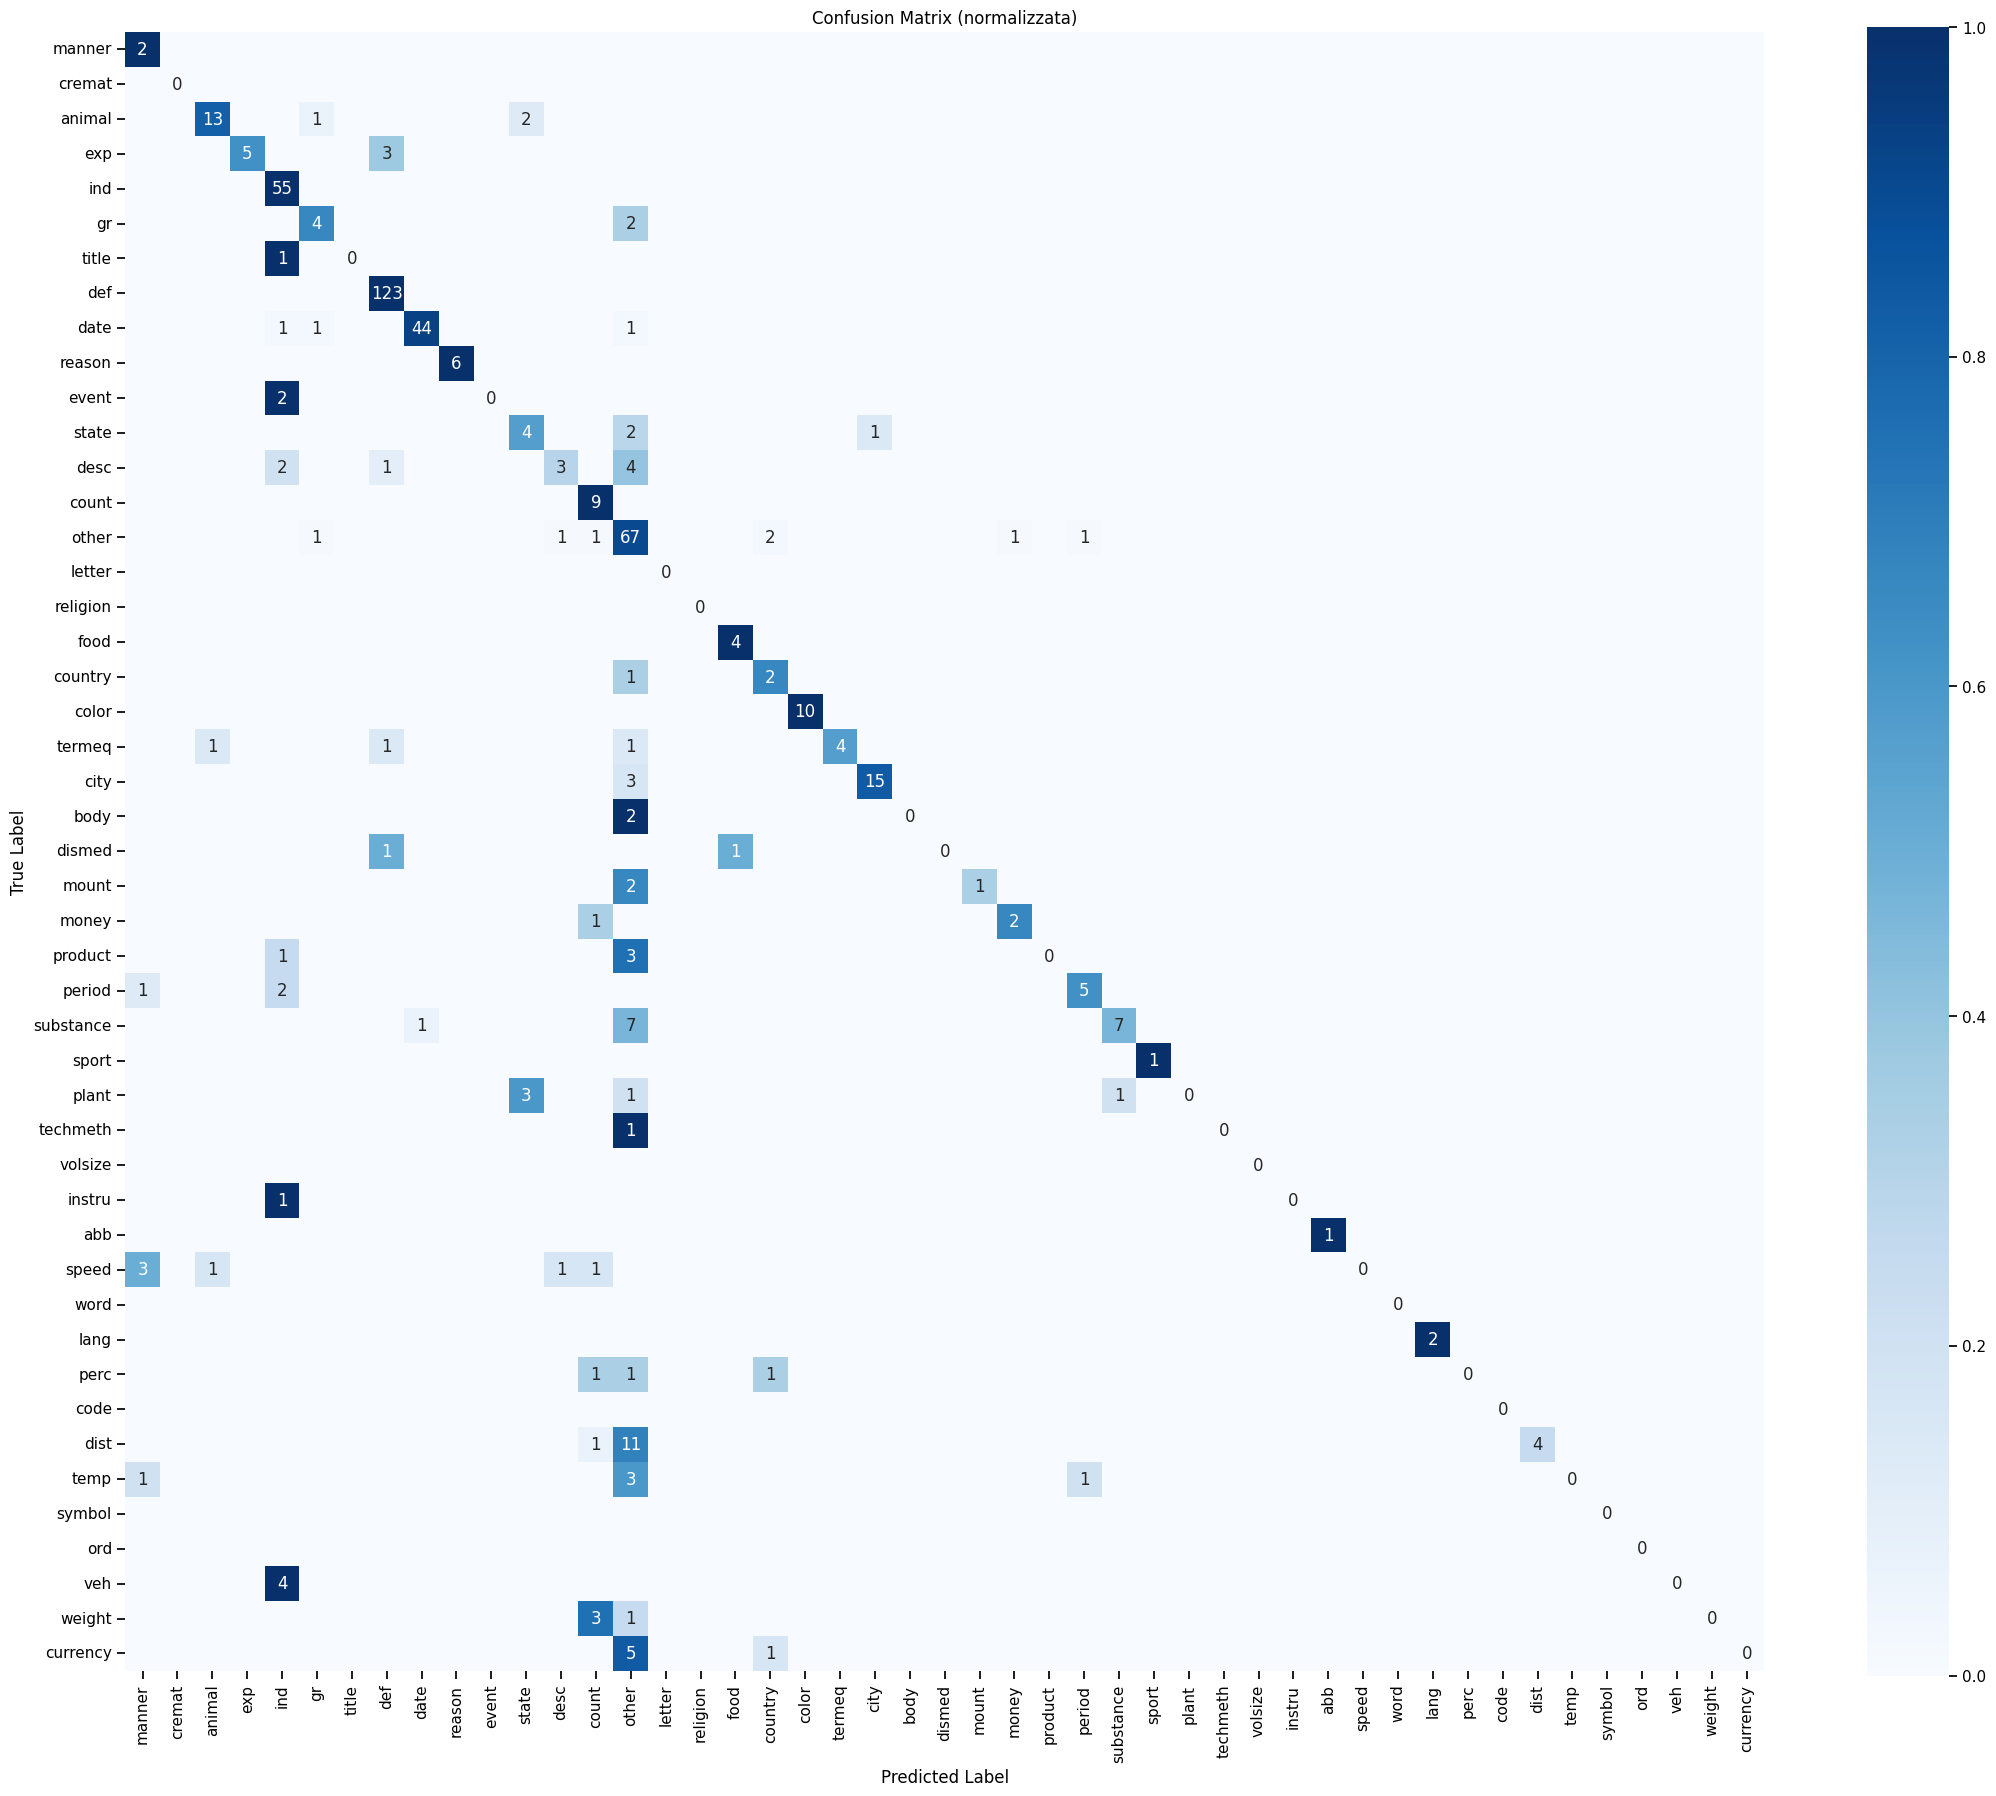

-- -- -- 

Some classification examples:
-- -- --
Some correctly classified examples (max 5):

Question: Where is the volcano Mauna Loa ?
True Label: 14, Prediction: 14
---
Question: Who was the abolitionist who led the raid on Harper 's Ferry in 1859 ?
True Label: 4, Prediction: 4
---
Question: When was Lyndon B. Johnson born ?
True Label: 8, Prediction: 8
---


Some misclassified examples (max 5):

Question: What is the only artery that carries blue blood from the heart to the lungs ?
True Label: 22, Prediction: 14
---
Question: What is the criterion for being legally blind ?
True Label: 14, Prediction: 12
---
Question: What metal has the highest melting point ?
True Label: 28, Prediction: 14
---
Question: What is the effect of acid rain ?
True Label: 12, Prediction: 14
---
Question: What is the average body temperature ?
True Label: 41, Prediction: 27
---
-- -- --


In [ ]:
print("f1 scores:")
print("-- -- --")
print_f1_scores(tfidf_feat_reg_out)
print("-- -- -- \n")

print("confusion matrix:")
print("-- -- --")
plot_confusion_matrix(tfidf_feat_reg_out)
print("-- -- -- \n")

print("Some classification examples:")
print("-- -- --")
show_examples(test_text, tfidf_feat_reg_out)
print("-- -- --")

## Linear SVM

In [ ]:
# Creation of the Linear SVM model
tfidf_feat_svm_model = LinearSVC(random_state=42)

In [ ]:
tfidf_feat_svm_model.fit(train_tfidf_feat, train_label_fine)

tfidf_feat_svm_out = tfidf_feat_svm_model.predict(test_tfidf_feat)

print("Accuracy:", accuracy_score(test_label_fine, tfidf_feat_svm_out))

Accuracy: 0.892


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


f1 scores:
-- -- --
F1 micro: 0.892
F1 macro: 0.7820558013515537
F1 weighted: 0.8896179259634359
-- -- -- 

confusion matrix:
-- -- --


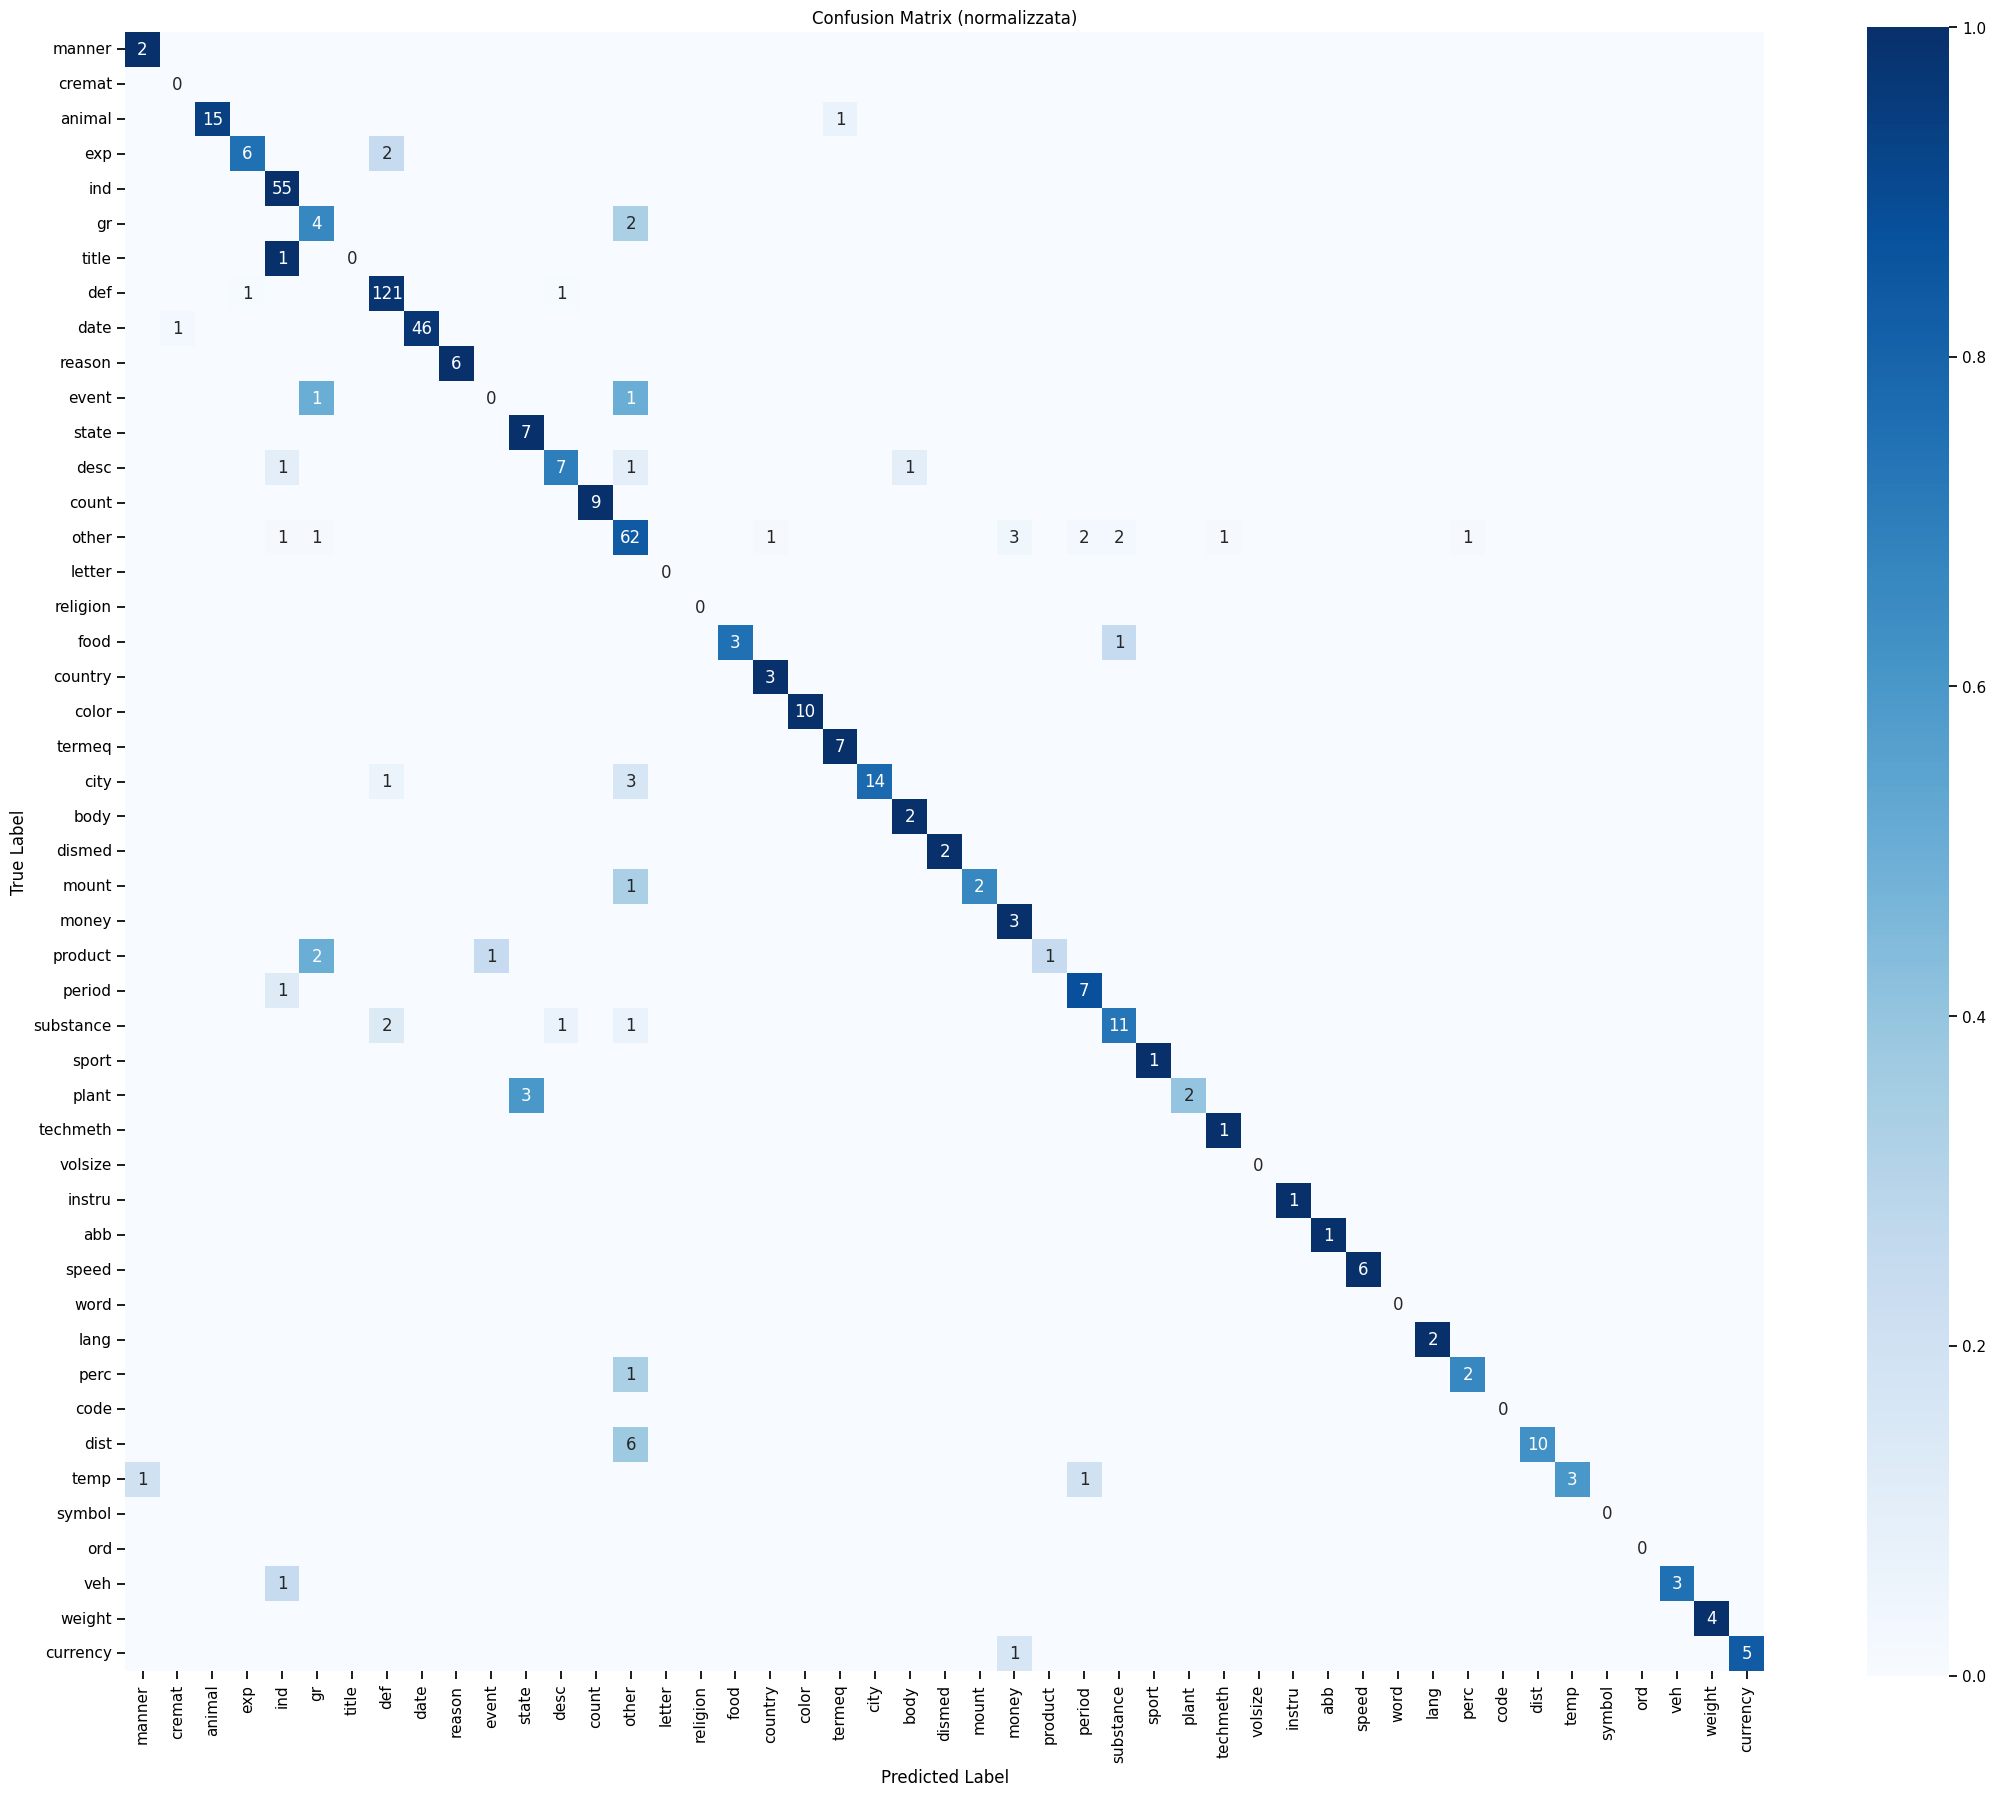

-- -- -- 

Some classification examples:
-- -- --
Some correctly classified examples (max 5):

Question: Where is the volcano Mauna Loa ?
True Label: 14, Prediction: 14
---
Question: Who was the abolitionist who led the raid on Harper 's Ferry in 1859 ?
True Label: 4, Prediction: 4
---
Question: When was Lyndon B. Johnson born ?
True Label: 8, Prediction: 8
---


Some misclassified examples (max 5):

Question: What is the criterion for being legally blind ?
True Label: 14, Prediction: 31
---
Question: What is the life expectancy of a dollar bill ?
True Label: 14, Prediction: 27
---
Question: What are the two houses of the Legislative branch ?
True Label: 14, Prediction: 4
---
Question: What is the average body temperature ?
True Label: 41, Prediction: 27
---
Question: What is the depth of the Nile river ?
True Label: 40, Prediction: 14
---
-- -- --


In [ ]:
print("f1 scores:")
print("-- -- --")
print_f1_scores(tfidf_feat_svm_out)
print("-- -- -- \n")

print("confusion matrix:")
print("-- -- --")
plot_confusion_matrix(tfidf_feat_svm_out)
print("-- -- -- \n")

print("Some classification examples:")
print("-- -- --")
show_examples(test_text, tfidf_feat_svm_out)
print("-- -- --")

# TEXT CLASSIFICATION - SBERT ONLY

## Logistic Regression

In [ ]:
# Logistic Regression Model (multiclass)
sbert_baseline_reg_model = LogisticRegression(
    max_iter=3000,
    multi_class='multinomial',
    solver='lbfgs',
    C=0.5,
    penalty='l2',
    n_jobs=-1,
    random_state=42
)

In [ ]:
# Train of the model
sbert_baseline_reg_model.fit(train_sbert, train_label_fine)

# Prediction
sbert_baseline_reg_out = sbert_baseline_reg_model.predict(test_sbert)

print("Accuracy:", accuracy_score(test_label_fine, sbert_baseline_reg_out))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.72


f1 scores:
-- -- --
F1 micro: 0.72
F1 macro: 0.3471530531602438
F1 weighted: 0.6752693771978102
-- -- -- 

confusion matrix:
-- -- --


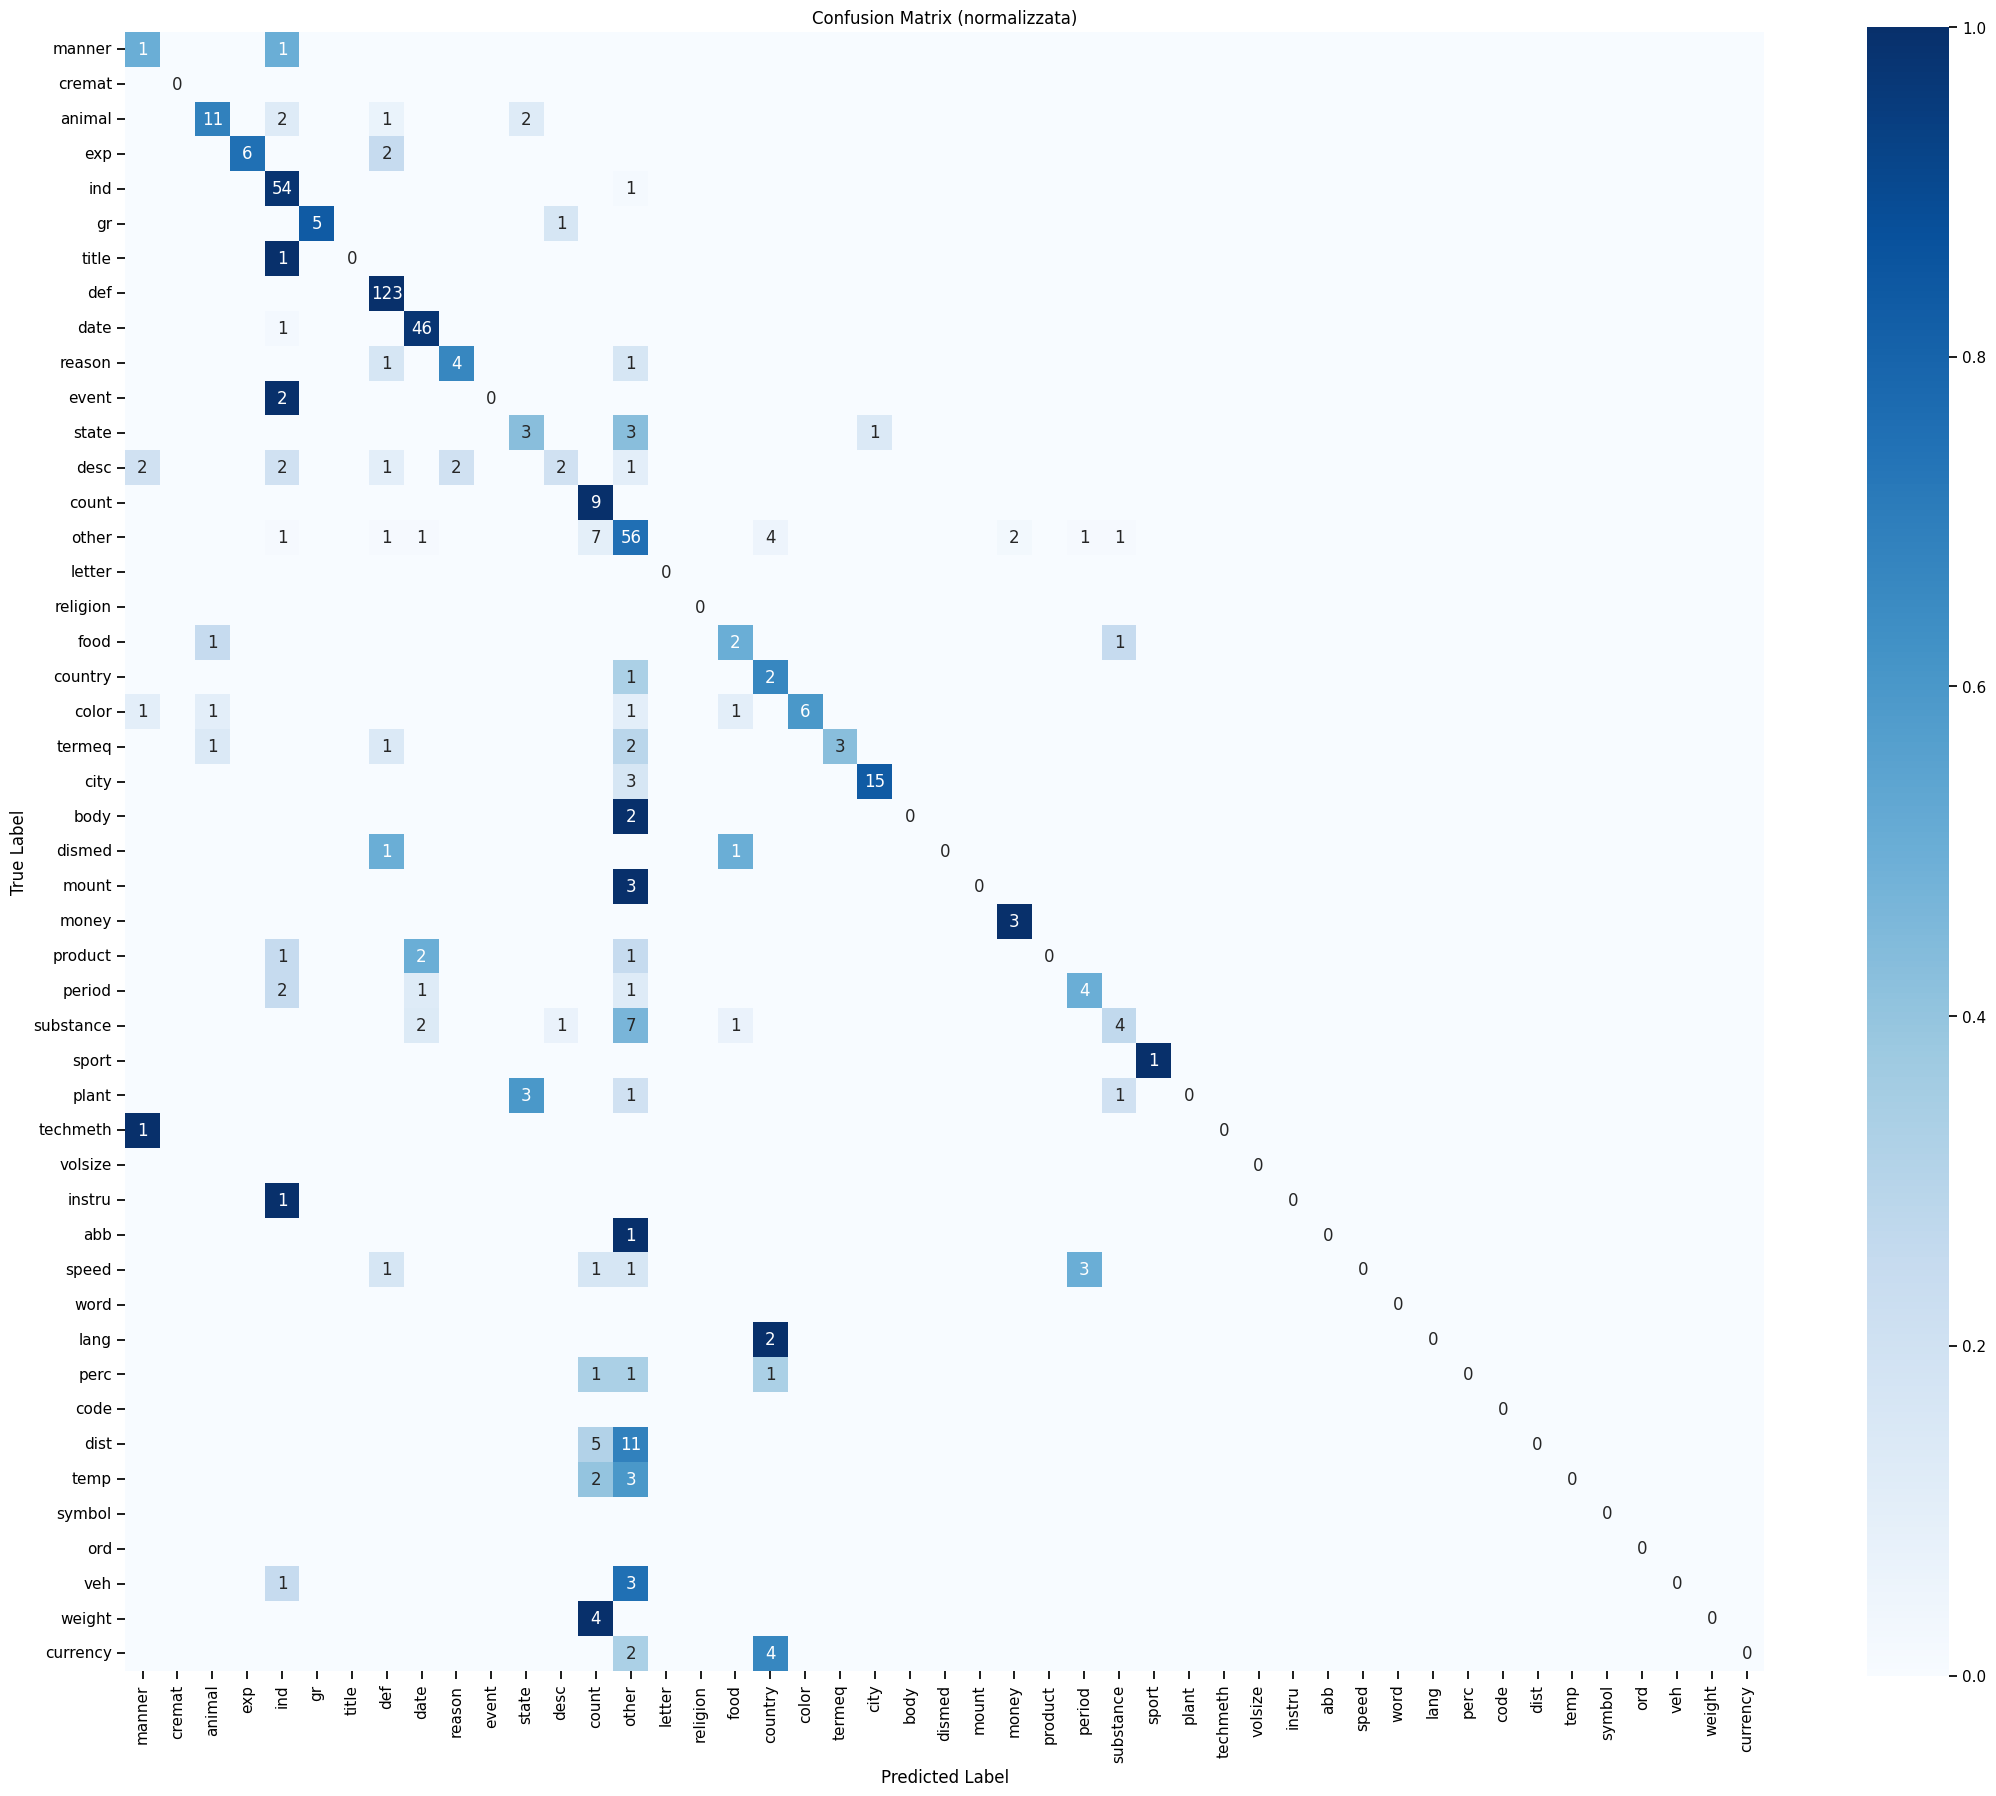

-- -- -- 

Some classification examples:
-- -- --
Some correctly classified examples (max 5):

Question: Where is the volcano Mauna Loa ?
True Label: 14, Prediction: 14
---
Question: Who was the abolitionist who led the raid on Harper 's Ferry in 1859 ?
True Label: 4, Prediction: 4
---
Question: When was Lyndon B. Johnson born ?
True Label: 8, Prediction: 8
---


Some misclassified examples (max 5):

Question: What is the only artery that carries blue blood from the heart to the lungs ?
True Label: 22, Prediction: 14
---
Question: How far is Pluto from the sun ?
True Label: 40, Prediction: 14
---
Question: What metal has the highest melting point ?
True Label: 28, Prediction: 14
---
Question: What is the effect of acid rain ?
True Label: 12, Prediction: 14
---
Question: What is the life expectancy of a dollar bill ?
True Label: 14, Prediction: 13
---
-- -- --


In [ ]:
print("f1 scores:")
print("-- -- --")
print_f1_scores(sbert_baseline_reg_out)
print("-- -- -- \n")

print("confusion matrix:")
print("-- -- --")
plot_confusion_matrix(sbert_baseline_reg_out)
print("-- -- -- \n")

print("Some classification examples:")
print("-- -- --")
show_examples(test_text, sbert_baseline_reg_out)
print("-- -- --")

## Linear SVM

In [ ]:
# Creation of the Linear SVM model
sbert_baseline_svm_model = LinearSVC(random_state=42)

In [ ]:
sbert_baseline_svm_model.fit(train_sbert, train_label_fine)

sbert_baseline_svm_out = sbert_baseline_svm_model.predict(test_sbert)

print("Accuracy:", accuracy_score(test_label_fine, sbert_baseline_svm_out))

Accuracy: 0.87


f1 scores:
-- -- --
F1 micro: 0.87
F1 macro: 0.7232885241265704
F1 weighted: 0.8680790860390982
-- -- -- 

confusion matrix:
-- -- --


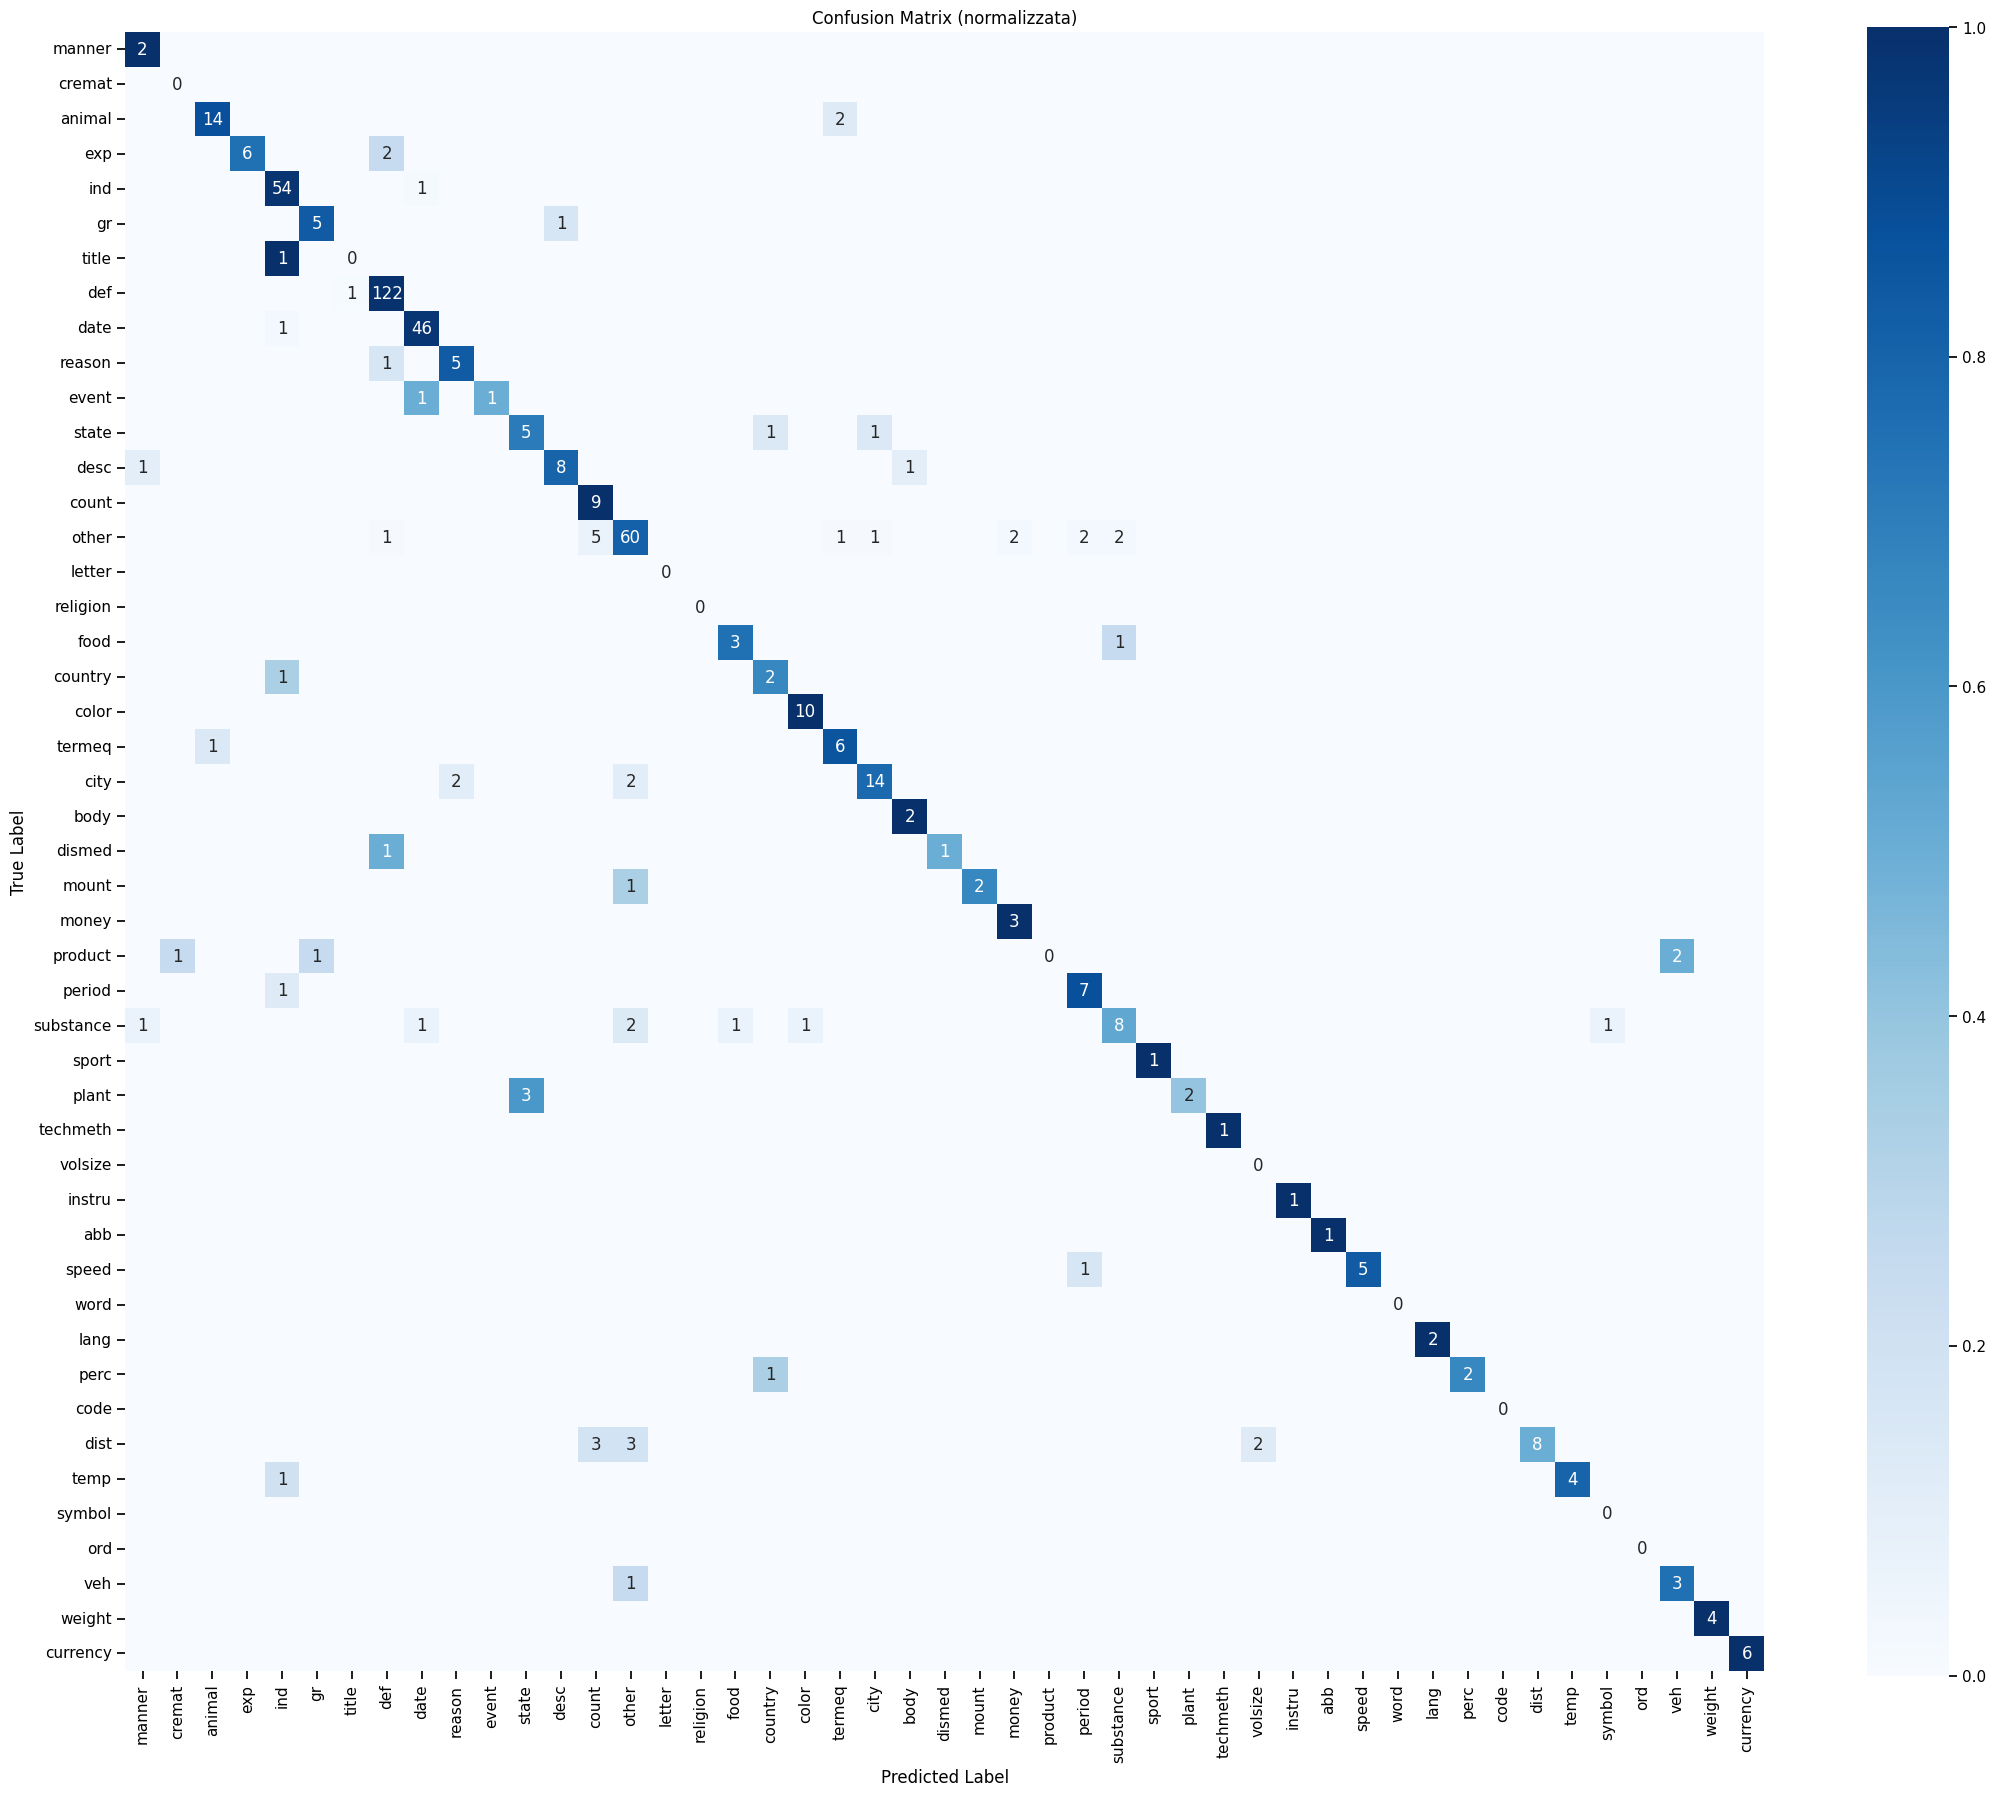

-- -- -- 

Some classification examples:
-- -- --
Some correctly classified examples (max 5):

Question: Where is the volcano Mauna Loa ?
True Label: 14, Prediction: 14
---
Question: Who was the abolitionist who led the raid on Harper 's Ferry in 1859 ?
True Label: 4, Prediction: 4
---
Question: When was Lyndon B. Johnson born ?
True Label: 8, Prediction: 8
---


Some misclassified examples (max 5):

Question: What is pastrami made of ?
True Label: 28, Prediction: 17
---
Question: What province is Montreal in ?
True Label: 11, Prediction: 21
---
Question: Why in tennis are zero points called love ?
True Label: 9, Prediction: 7
---
Question: What is the depth of the Nile river ?
True Label: 40, Prediction: 14
---
Question: How far is the service line from the net in tennis ?
True Label: 40, Prediction: 13
---
-- -- --


In [ ]:
print("f1 scores:")
print("-- -- --")
print_f1_scores(sbert_baseline_svm_out)
print("-- -- -- \n")

print("confusion matrix:")
print("-- -- --")
plot_confusion_matrix(sbert_baseline_svm_out)
print("-- -- -- \n")

print("Some classification examples:")
print("-- -- --")
show_examples(test_text, sbert_baseline_svm_out)
print("-- -- --")

# TEXT CLASSIFICATION - SBERT + CLUSTERING FEATURES

## Logistic Regression

In [ ]:
# Logistic Regression Model (multiclass)
sbert_feat_reg_model = LogisticRegression(
    max_iter=3000,
    multi_class='multinomial',
    solver='lbfgs',
    C=0.5,
    penalty='l2',
    n_jobs=-1,
    random_state=42
)

In [ ]:
# Train of the model
sbert_feat_reg_model.fit(train_sbert_feat, train_label_fine)

# Prediction
sbert_feat_reg_out = sbert_feat_reg_model.predict(test_sbert_feat)

print("Accuracy:", accuracy_score(test_label_fine, sbert_feat_reg_out))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.756


f1 scores:
-- -- --
F1 micro: 0.756
F1 macro: 0.4285581562559851
F1 weighted: 0.7221343772465486
-- -- -- 

confusion matrix:
-- -- --


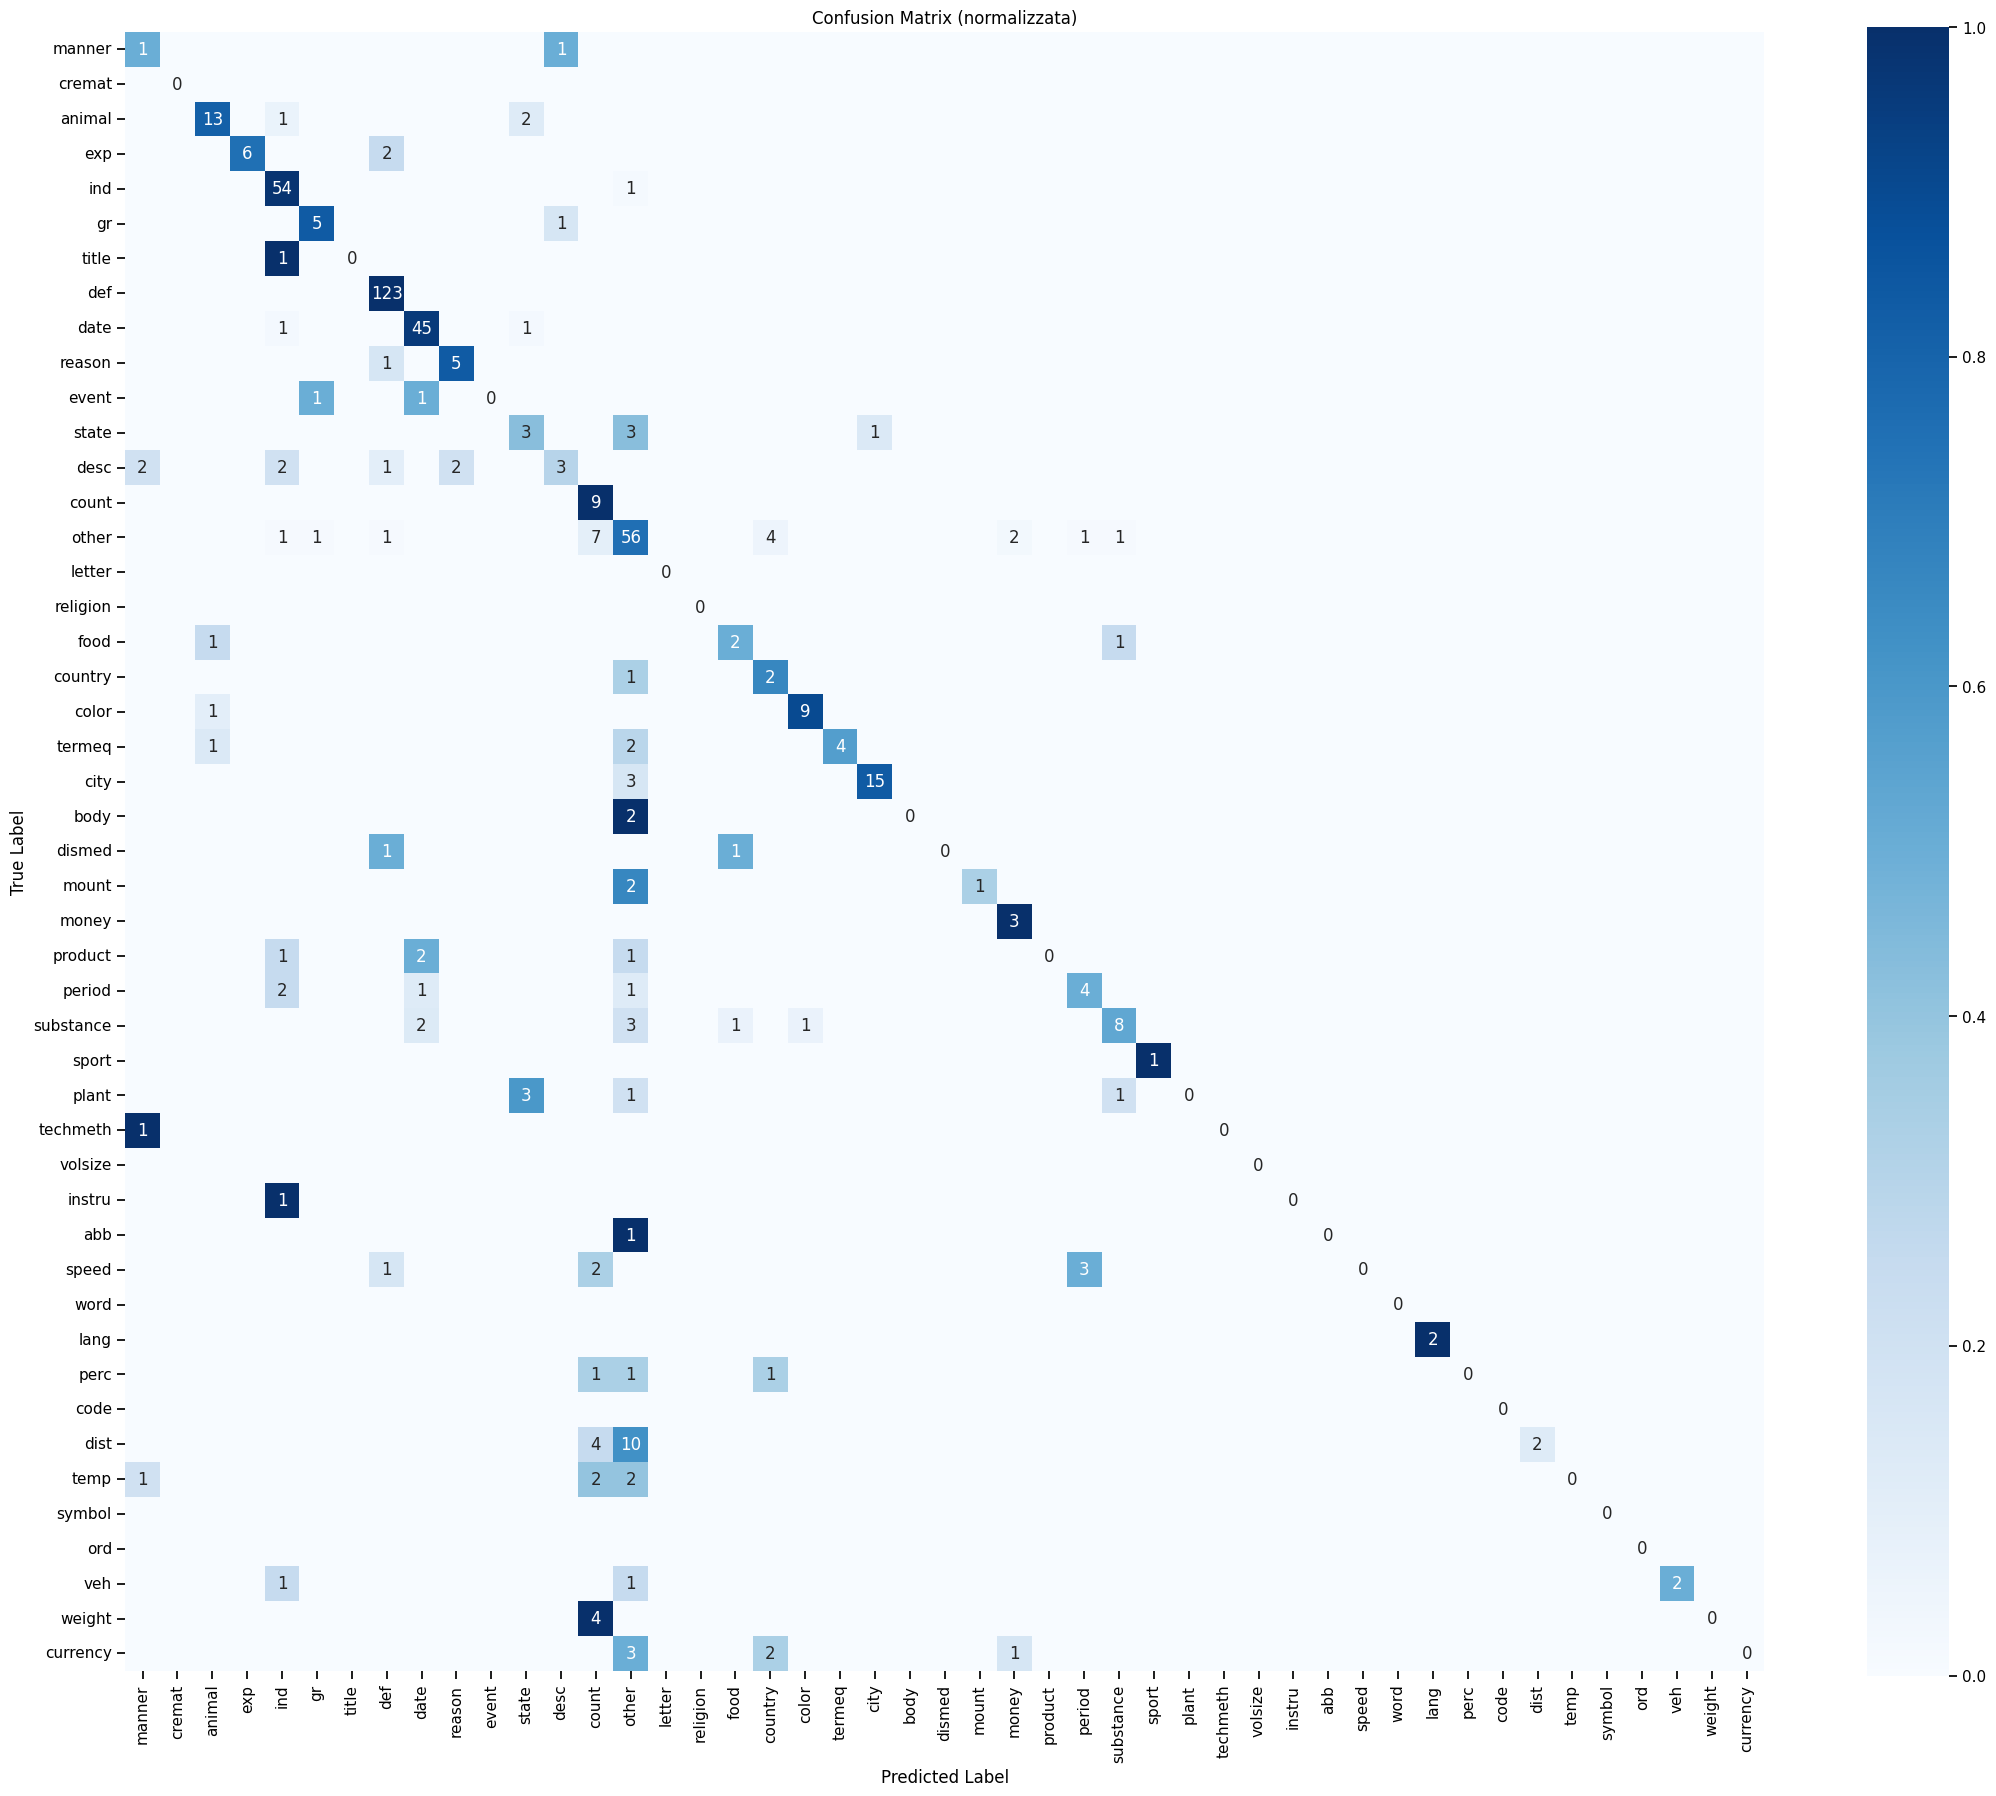

-- -- -- 

Some classification examples:
-- -- --
Some correctly classified examples (max 5):

Question: Where is the volcano Mauna Loa ?
True Label: 14, Prediction: 14
---
Question: Who was the abolitionist who led the raid on Harper 's Ferry in 1859 ?
True Label: 4, Prediction: 4
---
Question: When was Lyndon B. Johnson born ?
True Label: 8, Prediction: 8
---


Some misclassified examples (max 5):

Question: What is the only artery that carries blue blood from the heart to the lungs ?
True Label: 22, Prediction: 14
---
Question: How far is Pluto from the sun ?
True Label: 40, Prediction: 14
---
Question: What is the life expectancy of a dollar bill ?
True Label: 14, Prediction: 13
---
Question: What is pastrami made of ?
True Label: 28, Prediction: 17
---
Question: What is the average body temperature ?
True Label: 41, Prediction: 13
---
-- -- --


In [ ]:
print("f1 scores:")
print("-- -- --")
print_f1_scores(sbert_feat_reg_out)
print("-- -- -- \n")

print("confusion matrix:")
print("-- -- --")
plot_confusion_matrix(sbert_feat_reg_out)
print("-- -- -- \n")

print("Some classification examples:")
print("-- -- --")
show_examples(test_text, sbert_feat_reg_out)
print("-- -- --")

## Linear SVM

In [ ]:
# Creation of the Linear SVM model
sbert_feat_svm_model = LinearSVC(random_state=42)

In [ ]:
sbert_feat_svm_model.fit(train_sbert_feat, train_label_fine)

sbert_feat_svm_out = sbert_feat_svm_model.predict(test_sbert_feat)

print("Accuracy:", accuracy_score(test_label_fine, sbert_feat_svm_out))

Accuracy: 0.864


f1 scores:
-- -- --
F1 micro: 0.864
F1 macro: 0.7254424556790462
F1 weighted: 0.8621162312363726
-- -- -- 

confusion matrix:
-- -- --


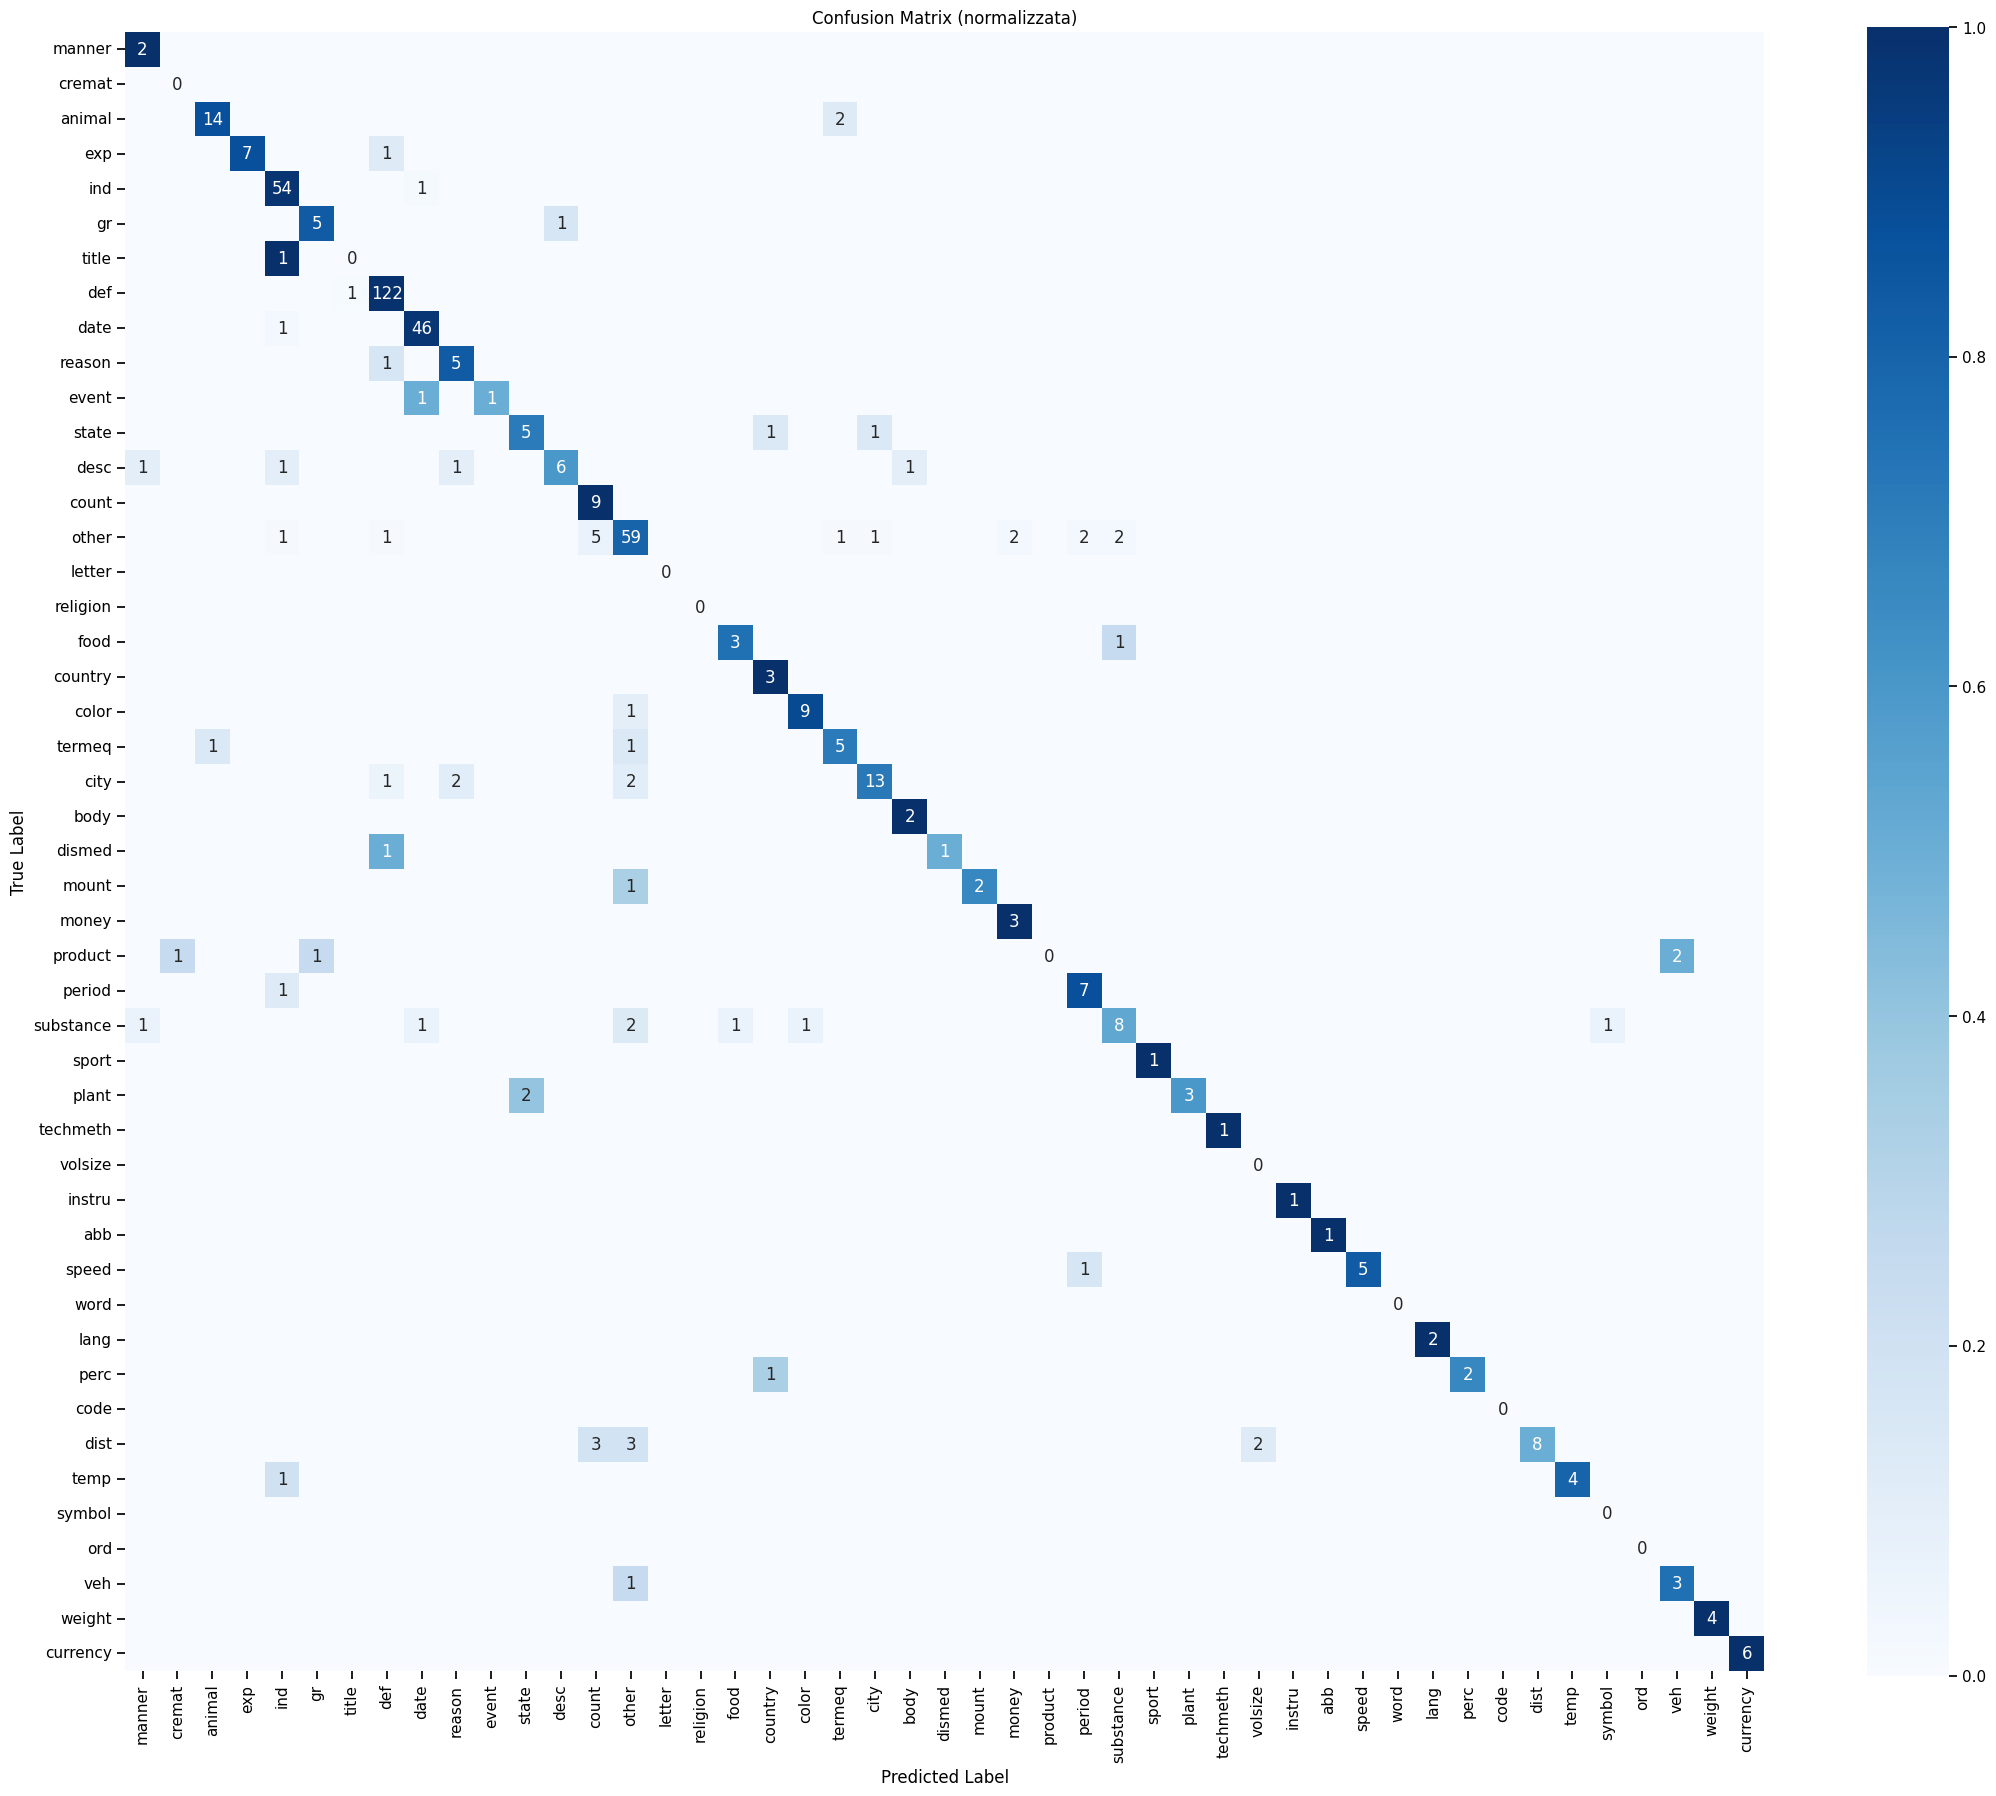

-- -- -- 

Some classification examples:
-- -- --
Some correctly classified examples (max 5):

Question: Where is the volcano Mauna Loa ?
True Label: 14, Prediction: 14
---
Question: Who was the abolitionist who led the raid on Harper 's Ferry in 1859 ?
True Label: 4, Prediction: 4
---
Question: When was Lyndon B. Johnson born ?
True Label: 8, Prediction: 8
---


Some misclassified examples (max 5):

Question: What is pastrami made of ?
True Label: 28, Prediction: 17
---
Question: What province is Montreal in ?
True Label: 11, Prediction: 21
---
Question: Why in tennis are zero points called love ?
True Label: 9, Prediction: 7
---
Question: What is the depth of the Nile river ?
True Label: 40, Prediction: 14
---
Question: How far is the service line from the net in tennis ?
True Label: 40, Prediction: 13
---
-- -- --


In [ ]:
print("f1 scores:")
print("-- -- --")
print_f1_scores(sbert_feat_svm_out)
print("-- -- -- \n")

print("confusion matrix:")
print("-- -- --")
plot_confusion_matrix(sbert_feat_svm_out)
print("-- -- -- \n")

print("Some classification examples:")
print("-- -- --")
show_examples(test_text, sbert_feat_svm_out)
print("-- -- --")

# TEXT CLASSIFICATION - TF-IDF + SBERT + CLUSTERING FEATURES

## Logistic Regression

In [ ]:
# Logistic Regression Model (multiclass)
full_reg_model = LogisticRegression(
    max_iter=3000,
    multi_class='multinomial',
    solver='lbfgs',
    C=0.5,
    penalty='l2',
    n_jobs=-1,
    random_state=42
)

In [ ]:
# Train of the model
full_reg_model.fit(train_full, train_label_fine)

# Prediction
full_reg_out = full_reg_model.predict(test_full)

print("Accuracy:", accuracy_score(test_label_fine, full_reg_out))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.814


f1 scores:
-- -- --
F1 micro: 0.814
F1 macro: 0.5456223472760692
F1 weighted: 0.7820305650719334
-- -- -- 

confusion matrix:
-- -- --


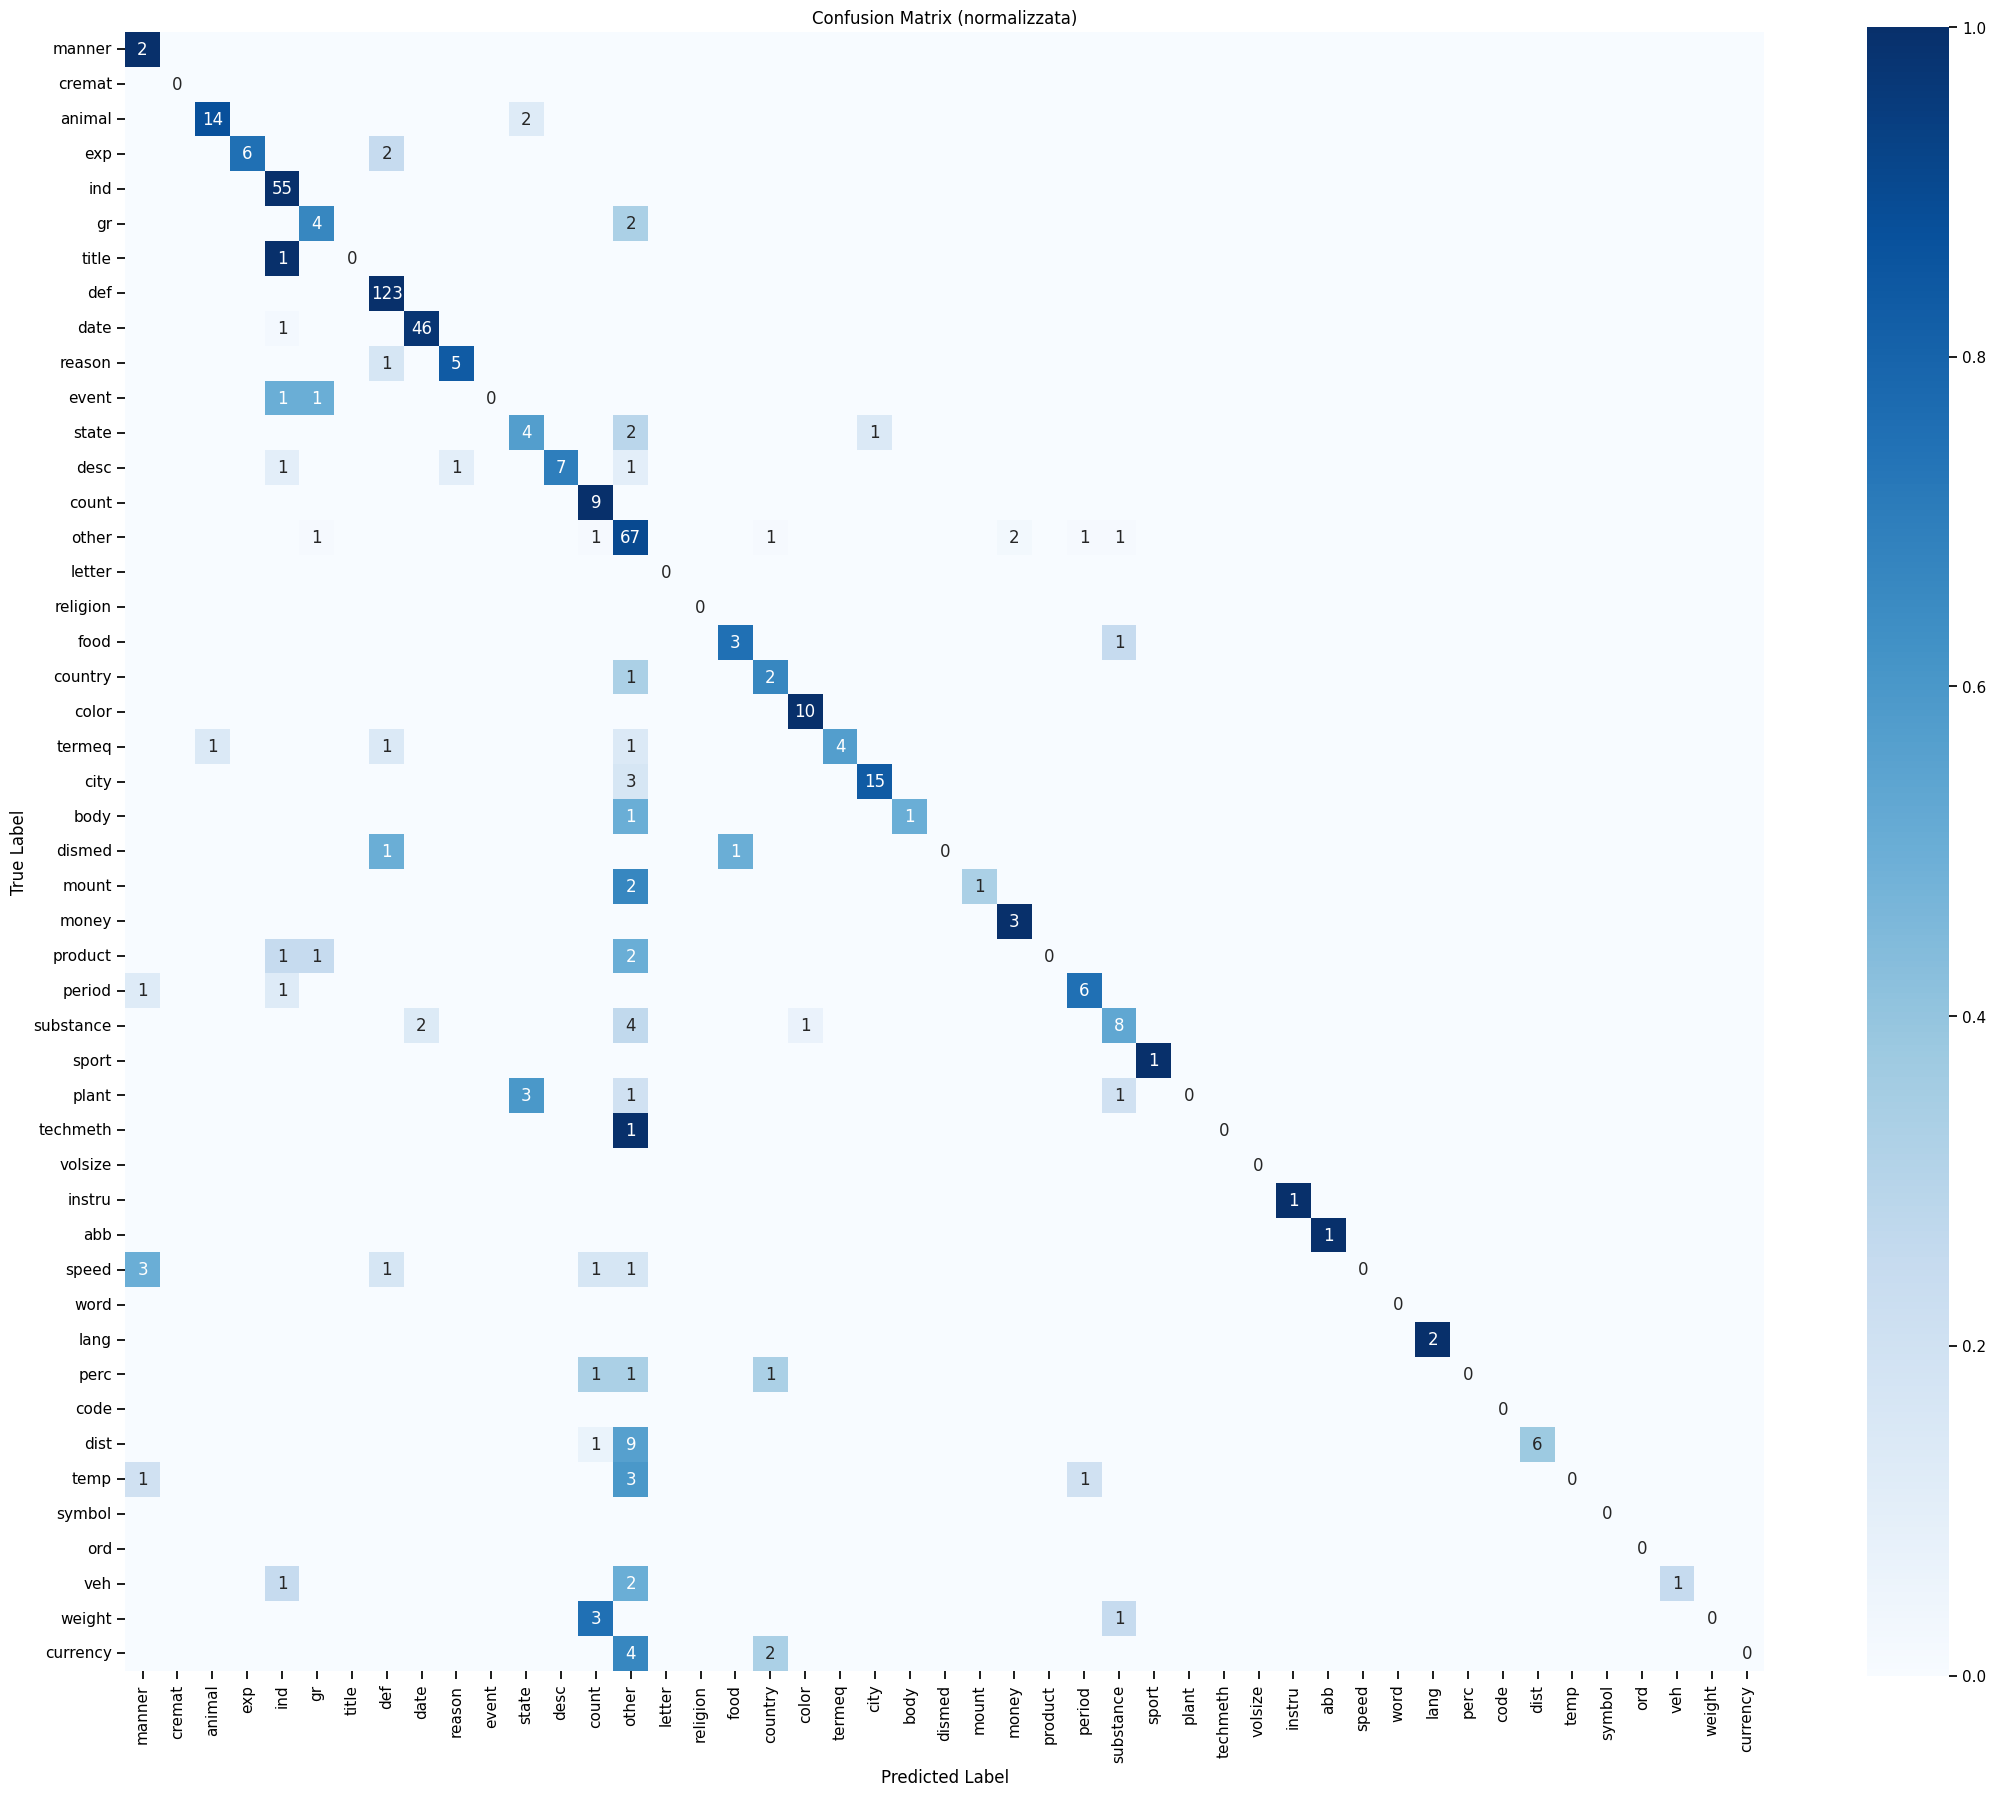

-- -- -- 

Some classification examples:
-- -- --
Some correctly classified examples (max 5):

Question: Where is the volcano Mauna Loa ?
True Label: 14, Prediction: 14
---
Question: Who was the abolitionist who led the raid on Harper 's Ferry in 1859 ?
True Label: 4, Prediction: 4
---
Question: When was Lyndon B. Johnson born ?
True Label: 8, Prediction: 8
---


Some misclassified examples (max 5):

Question: What is the only artery that carries blue blood from the heart to the lungs ?
True Label: 22, Prediction: 14
---
Question: What metal has the highest melting point ?
True Label: 28, Prediction: 14
---
Question: What is the average body temperature ?
True Label: 41, Prediction: 27
---
Question: What province is Montreal in ?
True Label: 11, Prediction: 21
---
Question: Why in tennis are zero points called love ?
True Label: 9, Prediction: 7
---
-- -- --


In [ ]:
print("f1 scores:")
print("-- -- --")
print_f1_scores(full_reg_out)
print("-- -- -- \n")

print("confusion matrix:")
print("-- -- --")
plot_confusion_matrix(full_reg_out)
print("-- -- -- \n")

print("Some classification examples:")
print("-- -- --")
show_examples(test_text, full_reg_out)
print("-- -- --")

## Linear SVM

In [ ]:
# Creation of the Linear SVM model
full_svm_model = LinearSVC(random_state=42)

In [ ]:
full_svm_model.fit(train_full, train_label_fine)

full_svm_out = full_svm_model.predict(test_full)

print("Accuracy:", accuracy_score(test_label_fine, full_svm_out))

Accuracy: 0.922


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


f1 scores:
-- -- --
F1 micro: 0.922
F1 macro: 0.8654972232579542
F1 weighted: 0.9191681412006235
-- -- -- 

confusion matrix:
-- -- --


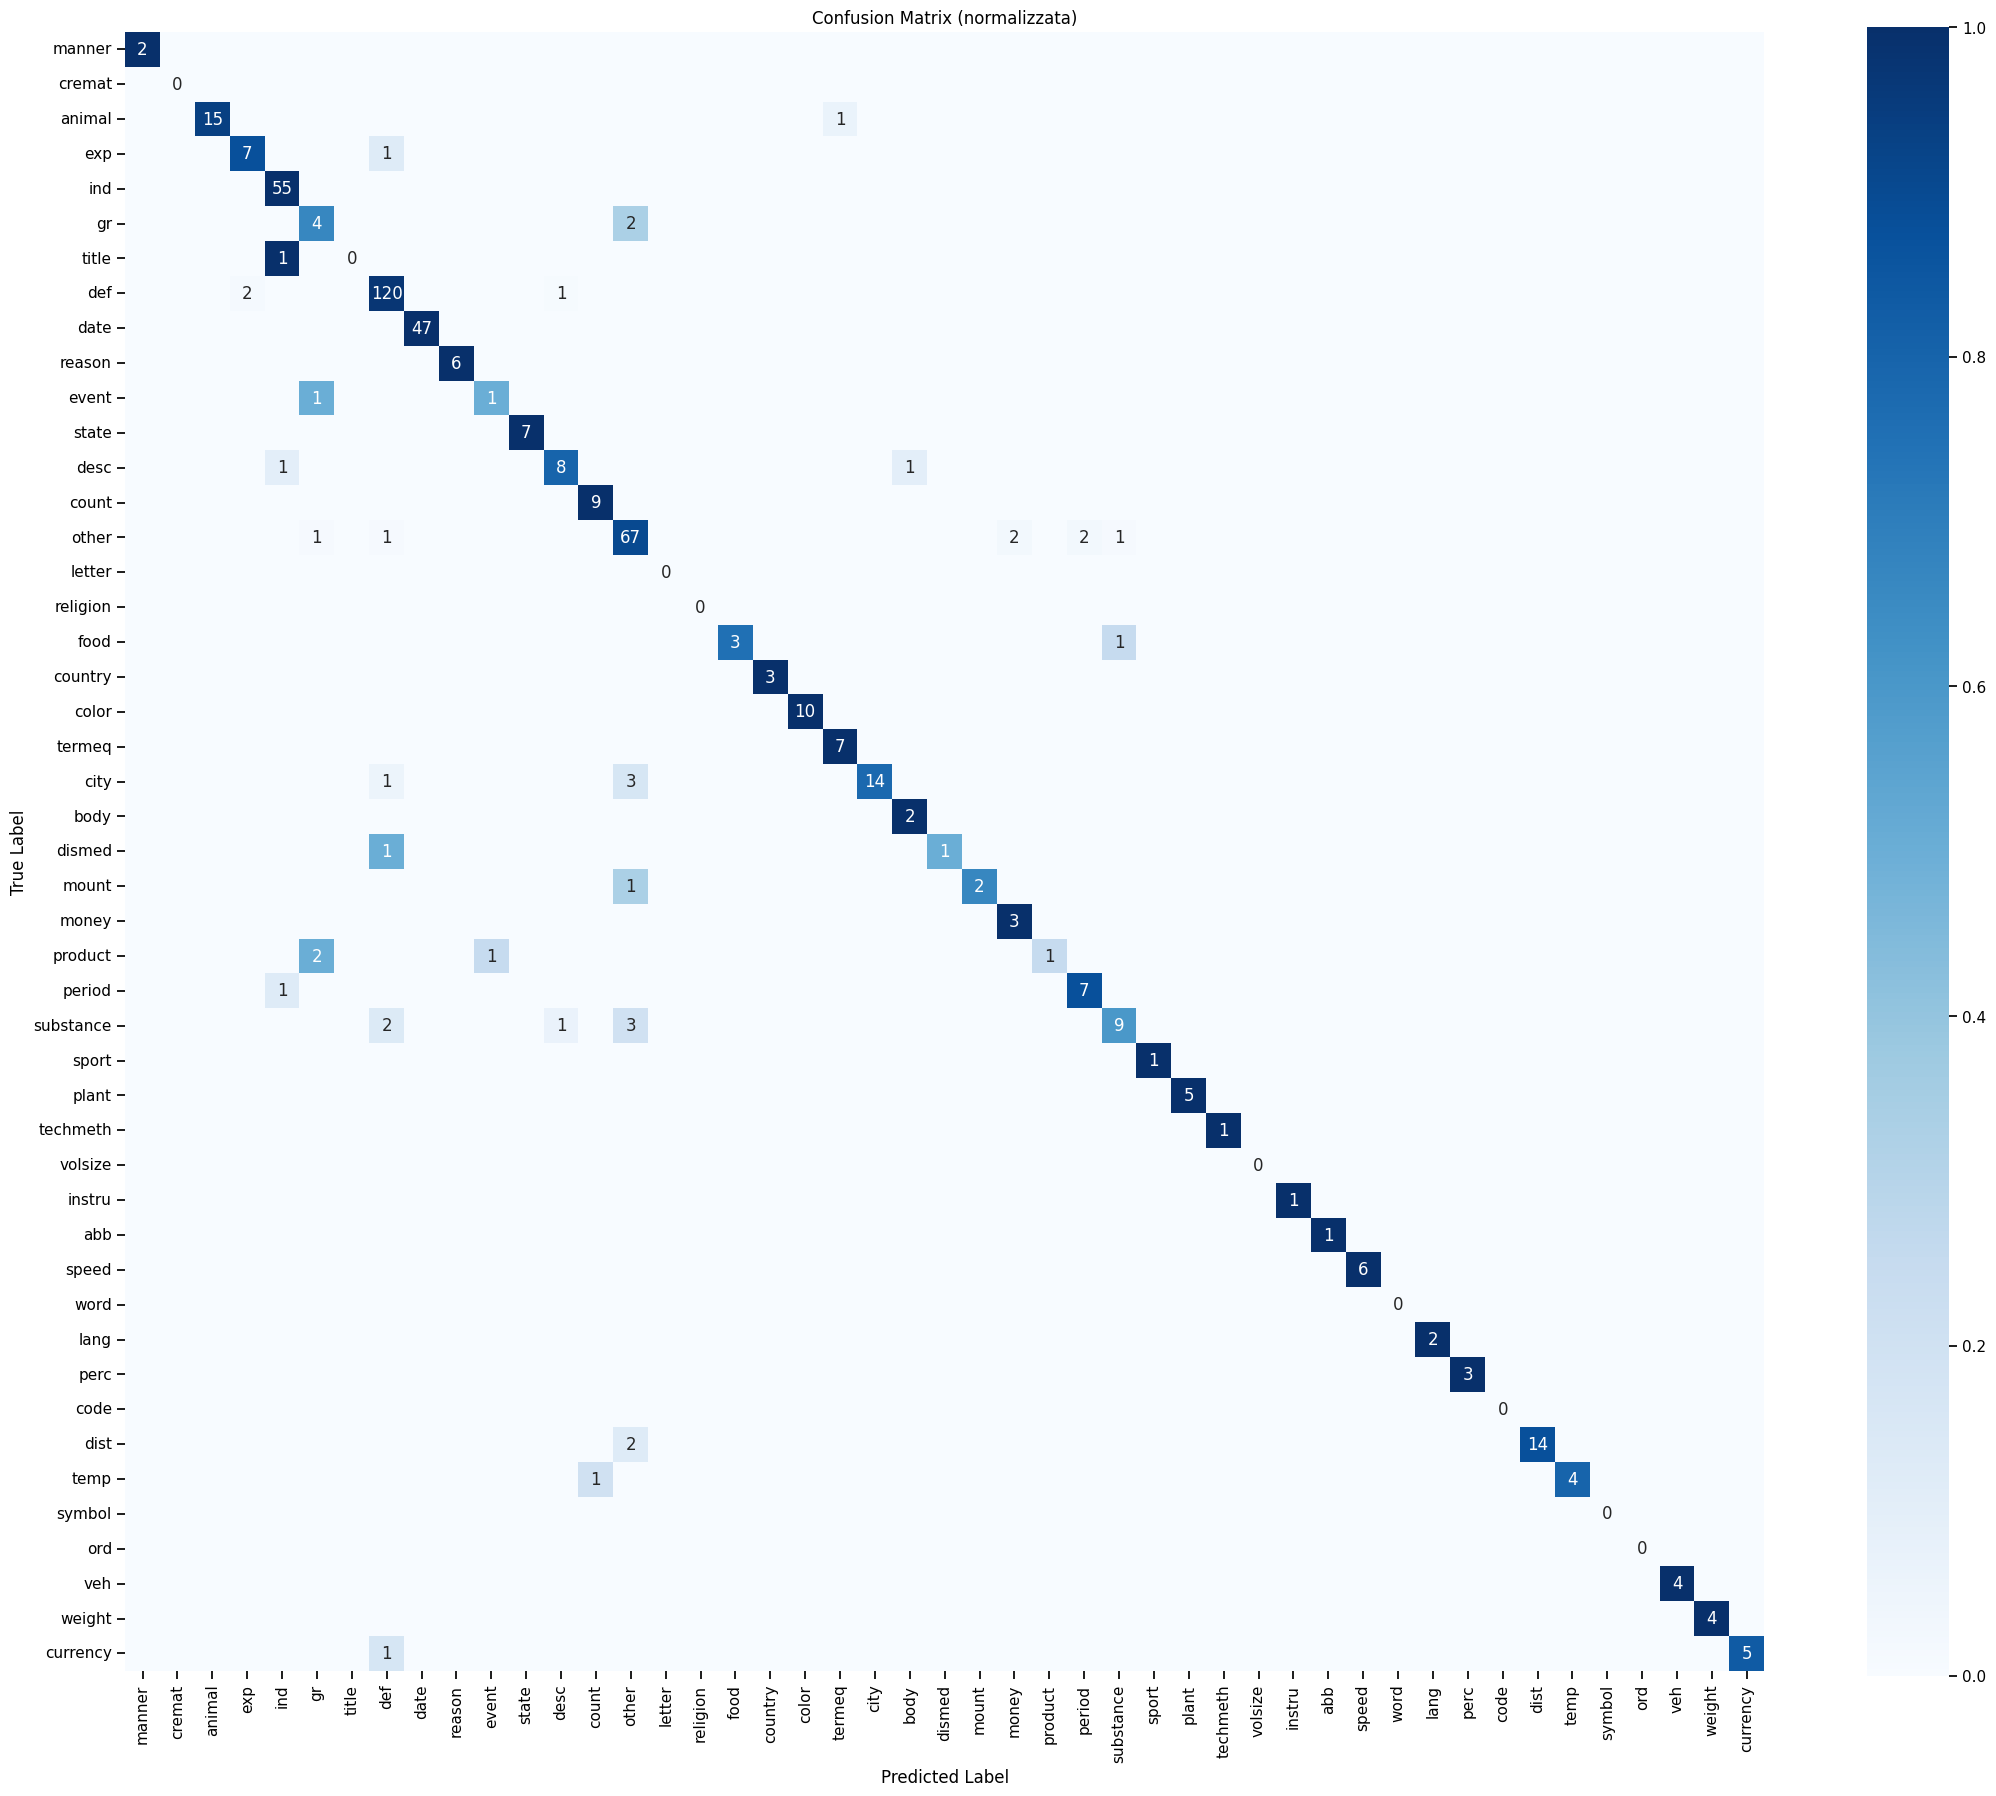

-- -- -- 

Some classification examples:
-- -- --
Some correctly classified examples (max 5):

Question: Where is the volcano Mauna Loa ?
True Label: 14, Prediction: 14
---
Question: Who was the abolitionist who led the raid on Harper 's Ferry in 1859 ?
True Label: 4, Prediction: 4
---
Question: When was Lyndon B. Johnson born ?
True Label: 8, Prediction: 8
---


Some misclassified examples (max 5):

Question: What is the life expectancy of a dollar bill ?
True Label: 14, Prediction: 27
---
Question: What is the depth of the Nile river ?
True Label: 40, Prediction: 14
---
Question: What is the sales tax in Minnesota ?
True Label: 14, Prediction: 25
---
Question: What is the longest major league baseball-winning streak ?
True Label: 14, Prediction: 5
---
Question: What birthstone is turquoise ?
True Label: 28, Prediction: 14
---
-- -- --


In [ ]:
print("f1 scores:")
print("-- -- --")
print_f1_scores(full_svm_out)
print("-- -- -- \n")

print("confusion matrix:")
print("-- -- --")
plot_confusion_matrix(full_svm_out)
print("-- -- -- \n")

print("Some classification examples:")
print("-- -- --")
show_examples(test_text, full_svm_out)
print("-- -- --")

# TEXT CLASSIFICATION RESULTS COMPARISON

In [ ]:
def compare_f1_scores(y_true, y_preds_dict):
    results = []

    for model_name, y_pred in y_preds_dict.items():
        f1_micro = f1_score(y_true, y_pred, average='micro')
        f1_macro = f1_score(y_true, y_pred, average='macro')
        f1_weighted = f1_score(y_true, y_pred, average='weighted')

        results.append({
            'Modello': model_name,
            'F1 Micro': f1_micro,
            'F1 Macro': f1_macro,
            'F1 Weighted': f1_weighted
        })

    df = pd.DataFrame(results)
    return df

In [ ]:
y_preds_dict = {
    'TF-IDF + Log Regression': tfidf_baseline_reg_out,
    'TF-IDF + SVM': tfidf_baseline_svm_out,
    'TF-IDF + Clustering + Log Regression': tfidf_feat_reg_out,
    'TF-IDF + Clustering + SVM': tfidf_feat_svm_out,
    'SBERT + Log Regression': sbert_baseline_reg_out,
    'SBERT + SVM': sbert_baseline_svm_out,
    'SBERT + Clustring + Log Regression': sbert_feat_reg_out,
    'SBERT + Clustring + SVM': sbert_feat_svm_out,
    'All Features + Log Regression': full_reg_out,
    'All Features + SVM': full_svm_out
}

df_f1 = compare_f1_scores(test_label_fine, y_preds_dict)
print(df_f1)

                                Modello  F1 Micro  F1 Macro  F1 Weighted
0               TF-IDF + Log Regression     0.676  0.286945     0.604668
1                          TF-IDF + SVM     0.844  0.739041     0.832791
2  TF-IDF + Clustering + Log Regression     0.786  0.475969     0.747150
3             TF-IDF + Clustering + SVM     0.892  0.782056     0.889618
4                SBERT + Log Regression     0.720  0.347153     0.675269
5                           SBERT + SVM     0.870  0.723289     0.868079
6    SBERT + Clustring + Log Regression     0.756  0.428558     0.722134
7               SBERT + Clustring + SVM     0.864  0.725442     0.862116
8         All Features + Log Regression     0.814  0.545622     0.782031
9                    All Features + SVM     0.922  0.865497     0.919168


In [ ]:
y_preds_dict_Log = {
    'TF-IDF + Log Regression': tfidf_baseline_reg_out,
    'TF-IDF + Clustering + Log Regression': tfidf_feat_reg_out,
    'SBERT + Log Regression': sbert_baseline_reg_out,
    'SBERT + Clustring + Log Regression': sbert_feat_reg_out,
    'All Features + Log Regression': full_reg_out
}

df_f1 = compare_f1_scores(test_label_fine, y_preds_dict_Log)
print(df_f1)

                                Modello  F1 Micro  F1 Macro  F1 Weighted
0               TF-IDF + Log Regression     0.676  0.286945     0.604668
1  TF-IDF + Clustering + Log Regression     0.786  0.475969     0.747150
2                SBERT + Log Regression     0.720  0.347153     0.675269
3    SBERT + Clustring + Log Regression     0.756  0.428558     0.722134
4         All Features + Log Regression     0.814  0.545622     0.782031


In [ ]:
y_preds_dict_SVM = {
    'TF-IDF + SVM': tfidf_baseline_svm_out,
    'TF-IDF + Clustering + SVM': tfidf_feat_svm_out,
    'SBERT + SVM': sbert_baseline_svm_out,
    'SBERT + Clustring + SVM': sbert_feat_svm_out,
    'All Features + SVM': full_svm_out
}

df_f1 = compare_f1_scores(test_label_fine, y_preds_dict_SVM)
print(df_f1)

                     Modello  F1 Micro  F1 Macro  F1 Weighted
0               TF-IDF + SVM     0.844  0.739041     0.832791
1  TF-IDF + Clustering + SVM     0.892  0.782056     0.889618
2                SBERT + SVM     0.870  0.723289     0.868079
3    SBERT + Clustring + SVM     0.864  0.725442     0.862116
4         All Features + SVM     0.922  0.865497     0.919168


# Error Analysis

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support
)

# Classification report

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT (Fine-Grained)")
print("=" * 70)

report = classification_report(test_label_fine, full_svm_out)
print(report)

report_dict = classification_report(test_label_fine, full_svm_out, output_dict=True)


CLASSIFICATION REPORT (Fine-Grained)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           2       1.00      0.94      0.97        16
           3       0.78      0.88      0.82         8
           4       0.95      1.00      0.97        55
           5       0.50      0.67      0.57         6
           6       0.00      0.00      0.00         1
           7       0.94      0.98      0.96       123
           8       1.00      1.00      1.00        47
           9       1.00      1.00      1.00         6
          10       0.50      0.50      0.50         2
          11       1.00      1.00      1.00         7
          12       0.80      0.80      0.80        10
          13       0.90      1.00      0.95         9
          14       0.86      0.91      0.88        74
          17       1.00      0.75      0.86         4
          18       1.00      1.00      1.00         3
          19       1.00      1.00      1.00

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


CONFUSION MATRIX (Coarse-Level)


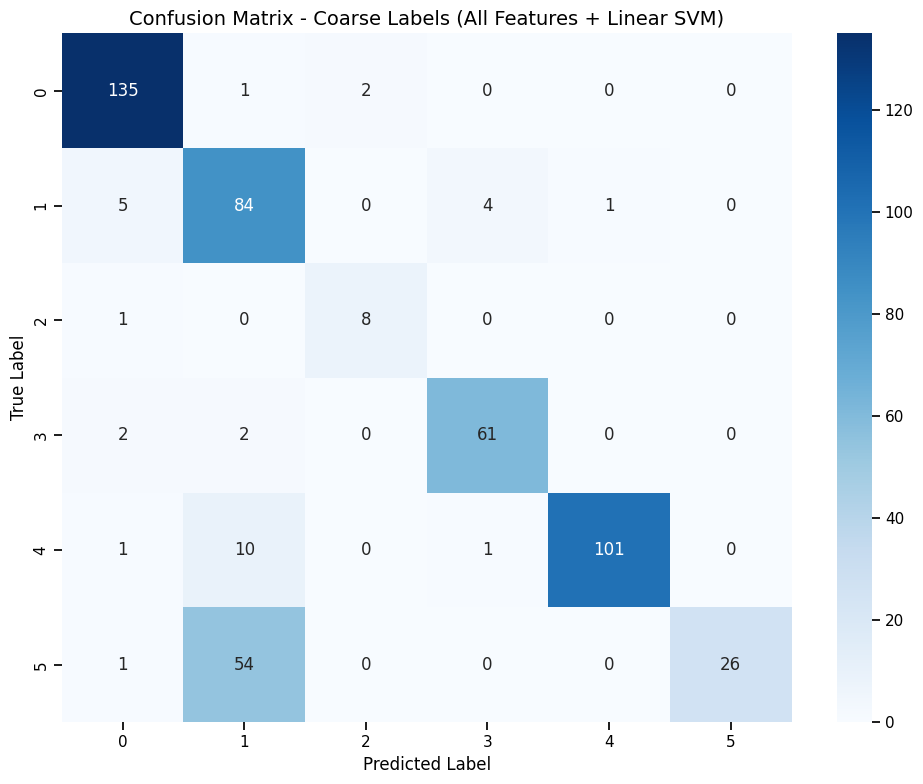

Saved: confusion_matrix_coarse.png

Confusion Matrix (Coarse-Level):

| True \ Pred | 0 | 1 | 2 | 3 | 4 | 5 |
|-------------|------------------------------------------
| 0 | 135 | 1 | 2 | 0 | 0 | 0 |
| 1 | 5 | 84 | 0 | 4 | 1 | 0 |
| 2 | 1 | 0 | 8 | 0 | 0 | 0 |
| 3 | 2 | 2 | 0 | 61 | 0 | 0 |
| 4 | 1 | 10 | 0 | 1 | 101 | 0 |
| 5 | 1 | 54 | 0 | 0 | 0 | 26 |


In [87]:
# Confusion Matrix (coarse)

print("\n" + "=" * 70)
print("CONFUSION MATRIX (Coarse-Level)")
print("=" * 70)


# Create map: fine_label -> coarse_label
fine_to_coarse_map = dict(zip(train_label_fine, train_label_coarse))

# Map the prediction to coarse
pred_coarse = pd.Series(full_svm_out).map(fine_to_coarse_map)

# Manage the Nan values
if pred_coarse.isna().any():
    print(f"Warning: {pred_coarse.isna().sum()} predictions could not be mapped to coarse labels")
    pred_coarse = pred_coarse.fillna('UNKNOWN')

# Confusion matrix coarse
labels_coarse = sorted(test_label_coarse.unique())
cm_coarse = confusion_matrix(test_label_coarse, pred_coarse, labels=labels_coarse)

plt.figure(figsize=(10, 8))
sns.heatmap(
        cm_coarse,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=[str(label) for label in labels_coarse],
        yticklabels=[str(label) for label in labels_coarse]
)
plt.title('Confusion Matrix - Coarse Labels (All Features + Linear SVM)', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_coarse.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix_coarse.png")

# Print the matrix as table
print("\nConfusion Matrix (Coarse-Level):")
print("\n| True \\ Pred |", " | ".join([str(label) for label in labels_coarse]), "|")
print("|-------------|" + "-------" * len(labels_coarse))
for i, true_label in enumerate(labels_coarse):
    row = " | ".join([str(cm_coarse[i, j]) for j in range(len(labels_coarse))])
    print(f"| {true_label} | {row} |")


In [88]:
# Performance for coarse category

print("\n" + "=" * 70)
print("PERFORMANCE FOR COARSE CATEGORY")
print("=" * 70)

# Calculate precision, recall, f1 for each coarse category
precision_coarse, recall_coarse, f1_coarse, support_coarse = precision_recall_fscore_support(
    test_label_coarse, pred_coarse, labels=labels_coarse, average=None
)

print("\n| Coarse Category | Precision | Recall | F1-Score | Support |")
print("|-----------------|" + "-----------" * 5 + "|")
for i, label in enumerate(labels_coarse):
    print(f"| {label} | {precision_coarse[i]:.3f} | {recall_coarse[i]:.3f} | {f1_coarse[i]:.3f} | {support_coarse[i]} |")


PERFORMANCE FOR COARSE CATEGORY

| Coarse Category | Precision | Recall | F1-Score | Support |
|-----------------|-------------------------------------------------------|
| 0 | 0.931 | 0.978 | 0.954 | 138 |
| 1 | 0.556 | 0.894 | 0.686 | 94 |
| 2 | 0.800 | 0.889 | 0.842 | 9 |
| 3 | 0.924 | 0.938 | 0.931 | 65 |
| 4 | 0.990 | 0.894 | 0.940 | 113 |
| 5 | 1.000 | 0.321 | 0.486 | 81 |


In [89]:
# Pairs of most confused classes

print("\n" + "=" * 70)
print("PAIRS OF MOST CONFUSED CLASSES (Fine-Grained)")
print("=" * 70)

# Define labels_fine for this section
labels_fine = sorted(test_label_fine.unique())

# Calculate cm_fine
cm_fine = confusion_matrix(test_label_fine, full_svm_out, labels=labels_fine)

# Find the errors
errors = []
for i, true_label in enumerate(labels_fine):
    for j, pred_label in enumerate(labels_fine):
        if i != j and cm_fine[i, j] > 0:
            errors.append({
                'True Label': true_label,
                'Predicted Label': pred_label,
                'Count': cm_fine[i, j]
            })

errors_df = pd.DataFrame(errors).sort_values('Count', ascending=False)

print("\nTop 15 Most Confused Class Pairs:")
print("\n| Rank | True Label | Predicted Label | Count |")
print("|------|------------|-----------------|" + "-------" * 2 + "|")
for idx, row in errors_df.head(15).iterrows():
    rank = errors_df.head(15).index.get_loc(idx) + 1
    print(f"| {rank} | {row['True Label']} | {row['Predicted Label']} | {row['Count']} |")

# Save all the errors in a CSV
errors_df.to_csv('confusion_pairs.csv', index=False)
print("\nSaved: confusion_pairs.csv")



PAIRS OF MOST CONFUSED CLASSES (Fine-Grained)

Top 15 Most Confused Class Pairs:

| Rank | True Label | Predicted Label | Count |
|------|------------|-----------------|--------------|
| 1 | 28 | 14 | 3 |
| 2 | 21 | 14 | 3 |
| 3 | 5 | 14 | 2 |
| 4 | 7 | 3 | 2 |
| 5 | 14 | 27 | 2 |
| 6 | 26 | 5 | 2 |
| 7 | 40 | 14 | 2 |
| 8 | 28 | 7 | 2 |
| 9 | 14 | 25 | 2 |
| 10 | 3 | 7 | 1 |
| 11 | 6 | 4 | 1 |
| 12 | 2 | 20 | 1 |
| 13 | 14 | 7 | 1 |
| 14 | 14 | 5 | 1 |
| 15 | 12 | 22 | 1 |

Saved: confusion_pairs.csv


In [82]:
# Analysis of the errors

print("\n" + "=" * 70)
print("ANALYSIS OF THE ERRORS FOR QUESTION WORD")
print("=" * 70)

# Function for extracting question words
def get_question_word(text):
    first_word = str(text).strip().split()[0].lower()
    qwords = ['what', 'who', 'how', 'where', 'when', 'which', 'why', 'whom', 'whose']
    if first_word in qwords:
        return first_word.capitalize()
    elif first_word == 'name':
        return 'Name'
    else:
        return 'Other'

# Create DataFrame for analysis
test_analysis = pd.DataFrame({
    'text': test_text.values,
    'true_label': test_label_fine.values,
    'pred_label': full_svm_out,
    'correct': test_label_fine.values == full_svm_out
})
test_analysis['question_word'] = test_analysis['text'].apply(get_question_word)

# Calculate the accuracy for question word
accuracy_by_qword = test_analysis.groupby('question_word')['correct'].agg(['mean', 'sum', 'count'])
accuracy_by_qword.columns = ['Accuracy', 'Correct', 'Total']
accuracy_by_qword = accuracy_by_qword.sort_values('Total', ascending=False)

print("\n| Question Word | Accuracy | Correct | Total |")
print("|---------------|" + "-----------" * 3 + "|")
for qword, row in accuracy_by_qword.iterrows():
    print(f"| {qword} | {row['Accuracy']:.3f} | {int(row['Correct'])} | {int(row['Total'])} |")



ANALYSIS OF THE ERRORS FOR QUESTION WORD

| Question Word | Accuracy | Correct | Total |
|---------------|---------------------------------|
| What | 0.901 | 309 | 343 |
| Who | 0.979 | 46 | 47 |
| How | 0.939 | 31 | 33 |
| Where | 0.923 | 24 | 26 |
| When | 1.000 | 26 | 26 |
| Other | 1.000 | 13 | 13 |
| Which | 1.000 | 6 | 6 |
| Why | 1.000 | 4 | 4 |
| Name | 1.000 | 2 | 2 |


In [90]:
# Example of errors

print("\n" + "=" * 70)
print("EXAMPLE OF ERRORS (Sample)")
print("=" * 70)

# Show some examples of errors
errors_examples = test_analysis[test_analysis['correct'] == False].head(20)

print("\nSample of Misclassified Questions:")
print("-" * 100)
for idx, row in errors_examples.iterrows():
    print(f"Question: {row['text'][:80]}...")
    print(f"  True: {row['true_label']} | Predicted: {row['pred_label']}")
    print("-" * 100)


EXAMPLE OF ERRORS (Sample)

Sample of Misclassified Questions:
----------------------------------------------------------------------------------------------------
Question: What is the life expectancy of a dollar bill ?...
  True: 14 | Predicted: 27
----------------------------------------------------------------------------------------------------
Question: What is the depth of the Nile river ?...
  True: 40 | Predicted: 14
----------------------------------------------------------------------------------------------------
Question: What is the sales tax in Minnesota ?...
  True: 14 | Predicted: 25
----------------------------------------------------------------------------------------------------
Question: What is the longest major league baseball-winning streak ?...
  True: 14 | Predicted: 5
----------------------------------------------------------------------------------------------------
Question: What birthstone is turquoise ?...
  True: 28 | Predicted: 14
--------------------

In [91]:
# Most frequent errors for each class

print("\n" + "=" * 70)
print("MOST FREQUENT ERRORS FOR EACH CLASS")
print("=" * 70)

# For each class, find the most common wrong prediction
print("\n| True Class | Most Common Error | Error Count | Class Total | Error Rate |")
print("|------------|" + "-------------------" * 5 + "|")

for true_label in labels_fine:
    mask = test_label_fine == true_label
    if mask.sum() == 0:
        continue

    # Find prediction for this class
    preds_for_class = pd.Series(full_svm_out)[mask.values]

    # Find errors
    errors_for_class = preds_for_class[preds_for_class != true_label]

    if len(errors_for_class) > 0:
        most_common_error = errors_for_class.value_counts().index[0]
        error_count = errors_for_class.value_counts().iloc[0]
        total = mask.sum()
        error_rate = len(errors_for_class) / total
        print(f"| {true_label} | {most_common_error} | {error_count} | {total} | {error_rate:.2%} |")


MOST FREQUENT ERRORS FOR EACH CLASS

| True Class | Most Common Error | Error Count | Class Total | Error Rate |
|------------|-----------------------------------------------------------------------------------------------|
| 2 | 20 | 1 | 16 | 6.25% |
| 3 | 7 | 1 | 8 | 12.50% |
| 5 | 14 | 2 | 6 | 33.33% |
| 6 | 4 | 1 | 1 | 100.00% |
| 7 | 3 | 2 | 123 | 2.44% |
| 10 | 5 | 1 | 2 | 50.00% |
| 12 | 4 | 1 | 10 | 20.00% |
| 14 | 27 | 2 | 74 | 9.46% |
| 17 | 28 | 1 | 4 | 25.00% |
| 21 | 14 | 3 | 18 | 22.22% |
| 23 | 7 | 1 | 2 | 50.00% |
| 24 | 14 | 1 | 3 | 33.33% |
| 26 | 5 | 2 | 4 | 75.00% |
| 27 | 4 | 1 | 8 | 12.50% |
| 28 | 14 | 3 | 15 | 40.00% |
| 40 | 14 | 2 | 16 | 12.50% |
| 41 | 13 | 1 | 5 | 20.00% |
| 46 | 7 | 1 | 6 | 16.67% |


In [92]:
# Recap


print("\n" + "=" * 70)
print("Recap")
print("=" * 70)

total_test = len(test_label_fine)
total_correct = (test_label_fine.values == full_svm_out).sum()
total_errors = total_test - total_correct

print(f"\nTotal Test Samples: {total_test}")
print(f"Correctly Classified: {total_correct} ({total_correct/total_test*100:.2f}%)")
print(f"Misclassified: {total_errors} ({total_errors/total_test*100:.2f}%)")

# Errors for coarse category
print("\nErrors by Coarse Category:")
test_analysis['true_coarse'] = test_label_coarse.values
errors_by_coarse = test_analysis.groupby('true_coarse')['correct'].agg(
    ['sum', 'count', lambda x: (1-x.mean())*100]
)
errors_by_coarse.columns = ['Correct', 'Total', 'Error Rate (%)']

print("\n| Coarse Category | Correct | Total | Error Rate |")
print("|-----------------|" + "-----------" * 3 + "|")
for coarse, row in errors_by_coarse.iterrows():
    print(f"| {coarse} | {int(row['Correct'])} | {int(row['Total'])} | {row['Error Rate (%)']:.2f}% |")


Recap

Total Test Samples: 500
Correctly Classified: 461 (92.20%)
Misclassified: 39 (7.80%)

Errors by Coarse Category:

| Coarse Category | Correct | Total | Error Rate |
|-----------------|---------------------------------|
| 0 | 134 | 138 | 2.90% |
| 1 | 78 | 94 | 17.02% |
| 2 | 8 | 9 | 11.11% |
| 3 | 61 | 65 | 6.15% |
| 4 | 104 | 113 | 7.96% |
| 5 | 76 | 81 | 6.17% |
